In [2010]:
import pandas as pd
import glob
import re
from pathlib import Path
import numpy as np        
from scipy.stats import randint, uniform
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import cross_validate, cross_val_score, train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, recall_score, make_scorer, f1_score, precision_recall_curve, average_precision_score, roc_auc_score, roc_curve, auc
from sklearn.utils.class_weight import compute_class_weight
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline 
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE

# Classifiers
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, callbacks

# from sklearn.svm import SVC
# from sklearn.decomposition import PCA



#import file
df_original = pd.read_csv('data/sstaudent_data.csv', sep=',')

## 1. EDA

1.1 What is the general shape of our data?

In [1963]:

print('\nShape of dataframe')
print('Original DF:', df_original.shape)
print(df_original.info())


Shape of dataframe
Original DF: (4424, 35)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 35 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Nationality                                     4424 non-null   int64  
 7   Mother's qualification                          4424 non-null   int64  
 8   Father's qualification                          4424 non-null   int64  
 9

In [1964]:
# standardize column names by lowercasign, removing spacial chars, and 

def standardize_column_names(this_df):    
    new_columns = []
    
    for col in this_df.columns:
        temp_col = str(col).lower()
        temp_col = temp_col.replace(' ', '_')
        temp_col = re.sub(r'[^a-z0-9_]', '', temp_col)
        
        new_columns.append(temp_col)
        
    this_df.columns = new_columns
    
    return this_df

df = standardize_column_names(df_original.copy()) 

1.2 Does our data have missing values?

In [1965]:
#check null rows - inverse of non-null values
print('\n# of Null Rows')
print(df.isnull().sum())


# of Null Rows
marital_status                                  0
application_mode                                0
application_order                               0
course                                          0
daytimeevening_attendance                       0
previous_qualification                          0
nationality                                     0
mothers_qualification                           0
fathers_qualification                           0
mothers_occupation                              0
fathers_occupation                              0
displaced                                       0
educational_special_needs                       0
debtor                                          0
tuition_fees_up_to_date                         0
gender                                          0
scholarship_holder                              0
age_at_enrollment                               0
international                                   0
curricular_units_1st_sem_credited 

1.3 What do our categorical variables look like?
Since data has been previously encoded, we build a dictionary to translate the encoding to the categorical definitions

In [1966]:
# Since data has been previously encoded, load in dictionaries

dictionary = {}
for f in glob.glob("data/dictionaries/*.csv"):
    cat_df = pd.read_csv(f)
    cat_df["combined"] =  cat_df["label"] #cat_df["value"].astype(str) + ": " +
    dictionary[Path(f).stem] = dict(zip(cat_df["value"], cat_df["combined"]))

print(dictionary)


{'tA10_yes_no': {0: 'No', 1: 'Yes'}, 'tA9_attendance_regime': {0: 'Evening', 1: 'Daytime'}, 'tA6_parent_previous_quals': {1: 'Secondary Education—12th Year of Schooling or Equivalent', 2: 'Higher Education—bachelor’s degree', 3: 'Higher Education—degree', 4: 'Higher Education—master’s degree', 5: 'Higher Education—doctorate', 6: 'Frequency of Higher Education', 7: '12th Year of Schooling—not completed', 8: '11th Year of Schooling—not completed', 9: '7th Year (Old)', 10: 'Other—11th Year of Schooling', 11: '2nd year complementary high school course', 12: '10th Year of Schooling', 13: 'General commerce course', 14: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equivalent', 15: 'Complementary High School Course', 16: 'Technical-professional course', 17: 'Complementary High School Course—not concluded', 18: '7th year of schooling', 19: '2nd cycle of the general high school course', 20: '9th Year of Schooling—not completed', 21: '8th year of schooling', 22: 'General Course of Administr

In [1967]:
# create new columns with the translated categoi=rical defintions

decoded_df = df.copy()
decoded_df['marital_status_decoded'] = df['marital_status'].map(dictionary['tA1_marital_status'])
decoded_df['application_mode_decoded'] = df['application_mode'].map(dictionary['tA3_application_mode'])
decoded_df['course_decoded'] = df['course'].map(dictionary['tA4_course_names'])
decoded_df['daytimeevening_attendance_decoded'] = df['daytimeevening_attendance'].map(dictionary['tA9_attendance_regime'])
decoded_df['previous_qualification_decoded'] = df['previous_qualification'].map(dictionary['tA5_previous_quals'])
decoded_df['nationality_decoded'] = df['application_mode'].map(dictionary['tA2_nationality'])
decoded_df['mothers_qualification_decoded'] = df['mothers_qualification'].map(dictionary['tA6_parent_previous_quals'])
decoded_df['fathers_qualification_decoded'] = df['fathers_qualification'].map(dictionary['tA6_parent_previous_quals'])
decoded_df['mothers_occupation_decoded'] = df['mothers_occupation'].map(dictionary['tA7_parent_occupation'])
decoded_df['fathers_occupation_decoded'] = df['fathers_occupation'].map(dictionary['tA7_parent_occupation'])
decoded_df['gender_decoded'] = df['gender'].map(dictionary['tA8_gender'])
decoded_df['displaced_decoded'] = df['displaced'].map(dictionary['tA10_yes_no'])
decoded_df['educational_special_needs_decoded'] = df['educational_special_needs'].map(dictionary['tA10_yes_no'])
decoded_df['tuition_fees_up_to_date_decoded'] = df['tuition_fees_up_to_date'].map(dictionary['tA10_yes_no'])
decoded_df['debtor_decoded'] = df['debtor'].map(dictionary['tA10_yes_no'])
decoded_df['scholarship_holder_decoded'] = df['scholarship_holder'].map(dictionary['tA10_yes_no'])
decoded_df['international_decoded'] = df['international'].map(dictionary['tA10_yes_no'])

print(decoded_df.head())


   marital_status  application_mode  application_order  course  daytimeevening_attendance  previous_qualification  nationality  \
0               1                 8                  5       2                          1                       1            1   
1               1                 6                  1      11                          1                       1            1   
2               1                 1                  5       5                          1                       1            1   
3               1                 8                  2      15                          1                       1            1   
4               2                12                  1       3                          0                       1            1   

   mothers_qualification  fathers_qualification  mothers_occupation  ...                      fathers_qualification_decoded  \
0                     13                     10                   6  ...                    

In [1968]:
# Make lists for  categorical columns
categorical_cols_orginal = ['marital_status', 'application_mode', 'course',
       'daytimeevening_attendance', 'previous_qualification', 'nationality',
       'mothers_qualification', 'fathers_qualification', 'mothers_occupation',
       'fathers_occupation', 'displaced', 'educational_special_needs',
       'debtor', 'tuition_fees_up_to_date', 'gender', 'scholarship_holder',
       'international']

# convert col type to categorical
for i, col in enumerate(categorical_cols_orginal):
   decoded_df[col] = decoded_df[col].astype('category')


       


Categorical Values by Column:


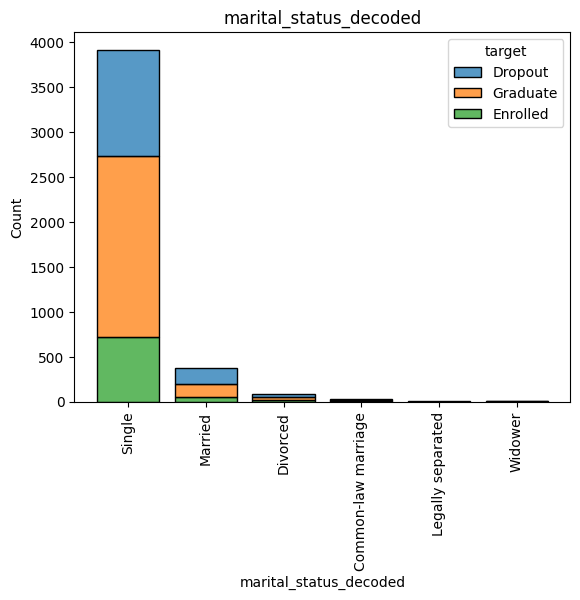


Values for DF column : marital_status_decoded
                        Count  Percentage
marital_status_decoded                   
Single                   3919       88.58
Married                   379        8.57
Divorced                   91        2.06
Common-law marriage        25        0.57
Legally separated           6        0.14
Widower                     4        0.09


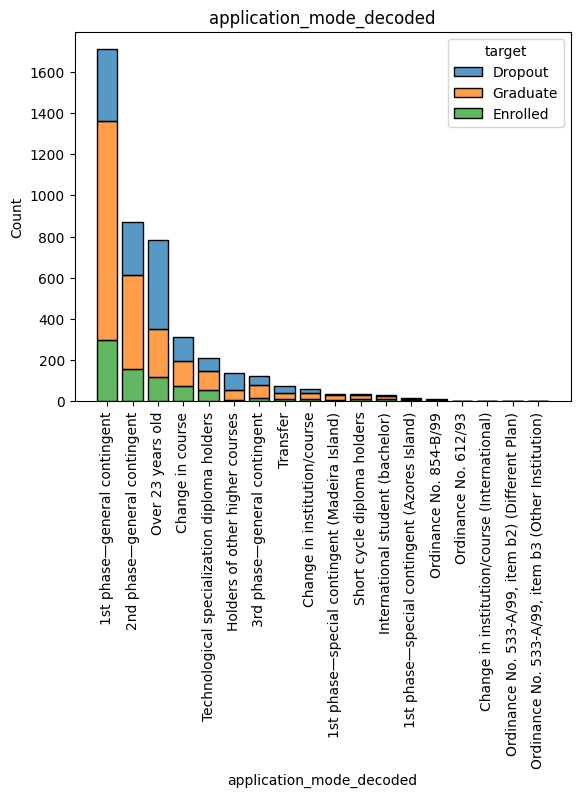


Values for DF column : application_mode_decoded
                                                    Count  Percentage
application_mode_decoded                                             
1st phase—general contingent                         1708       38.61
2nd phase—general contingent                          872       19.71
Over 23 years old                                     785       17.74
Change in course                                      312        7.05
Technological specialization diploma holders          213        4.81
Holders of other higher courses                       139        3.14
3rd phase—general contingent                          124        2.80
Transfer                                               77        1.74
Change in institution/course                           59        1.33
1st phase—special contingent (Madeira Island)          38        0.86
Short cycle diploma holders                            35        0.79
International student (bachelor)         

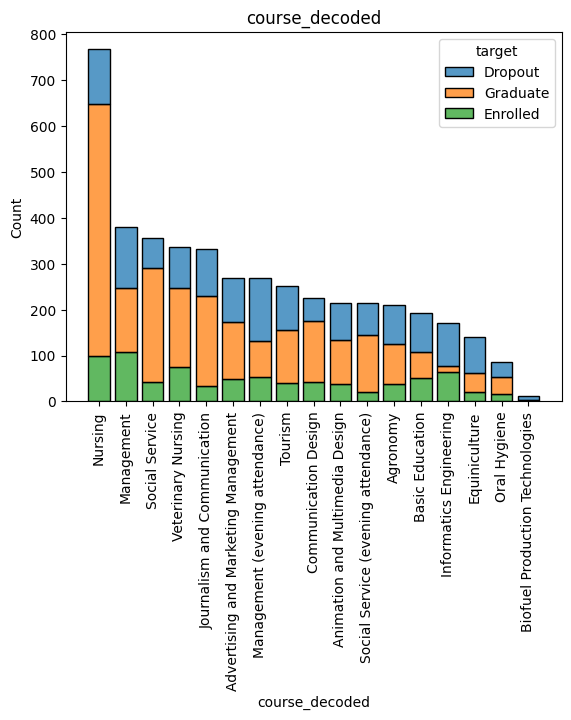


Values for DF column : course_decoded
                                      Count  Percentage
course_decoded                                         
Nursing                                 766       17.31
Management                              380        8.59
Social Service                          355        8.02
Veterinary Nursing                      337        7.62
Journalism and Communication            331        7.48
Advertising and Marketing Management    268        6.06
Management (evening attendance)         268        6.06
Tourism                                 252        5.70
Communication Design                    226        5.11
Animation and Multimedia Design         215        4.86
Social Service (evening attendance)     215        4.86
Agronomy                                210        4.75
Basic Education                         192        4.34
Informatics Engineering                 170        3.84
Equiniculture                           141        3.19
Oral Hygi

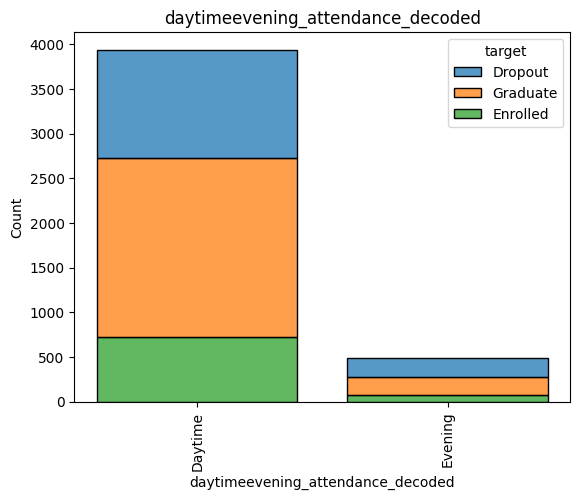


Values for DF column : daytimeevening_attendance_decoded
                                   Count  Percentage
daytimeevening_attendance_decoded                   
Daytime                             3941       89.08
Evening                              483       10.92


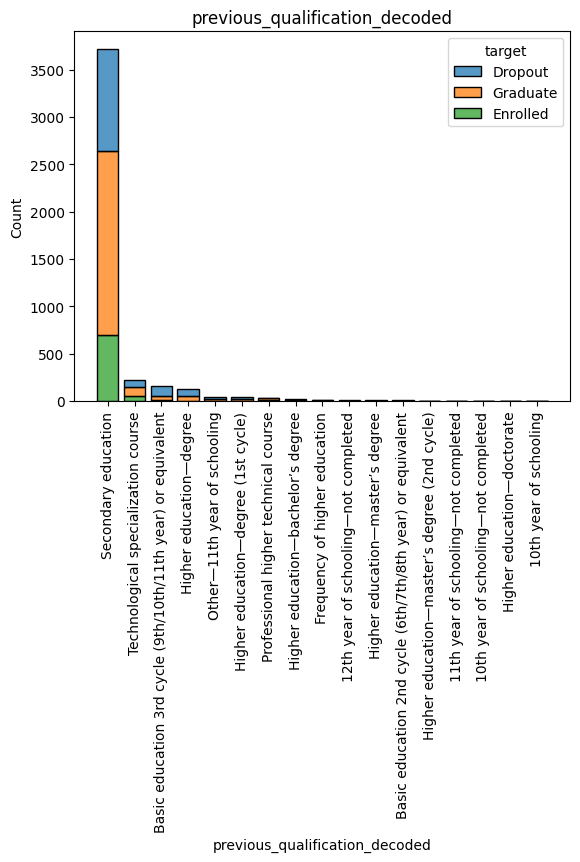


Values for DF column : previous_qualification_decoded
                                                    Count  Percentage
previous_qualification_decoded                                       
Secondary education                                  3717       84.02
Technological specialization course                   219        4.95
Basic education 3rd cycle (9th/10th/11th year) ...    162        3.66
Higher education—degree                               126        2.85
Other—11th year of schooling                           45        1.02
Higher education—degree (1st cycle)                    40        0.90
Professional higher technical course                   36        0.81
Higher education—bachelor’s degree                     23        0.52
Frequency of higher education                          16        0.36
12th year of schooling—not completed                   11        0.25
Higher education—master’s degree                        8        0.18
Basic education 2nd cycle (6th/7th/

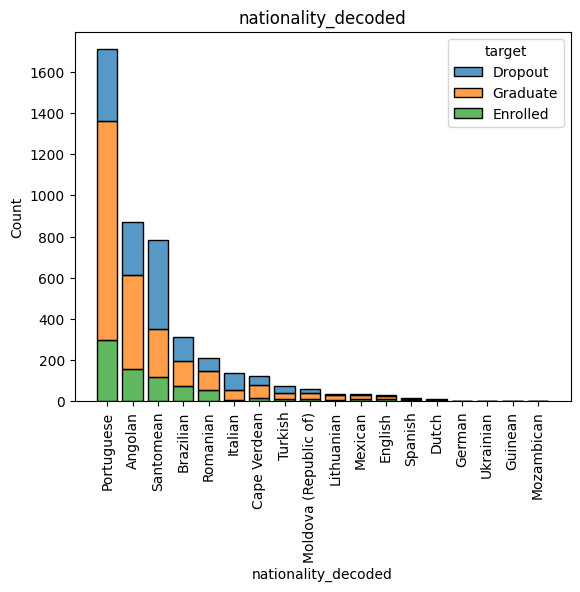


Values for DF column : nationality_decoded
                       Count  Percentage
nationality_decoded                     
Portuguese              1708       38.61
Angolan                  872       19.71
Santomean                785       17.74
Brazilian                312        7.05
Romanian                 213        4.81
Italian                  139        3.14
Cape Verdean             124        2.80
Turkish                   77        1.74
Moldova (Republic of)     59        1.33
Lithuanian                38        0.86
Mexican                   35        0.79
English                   30        0.68
Spanish                   16        0.36
Dutch                     10        0.23
German                     3        0.07
Ukrainian                  1        0.02
Guinean                    1        0.02
Mozambican                 1        0.02


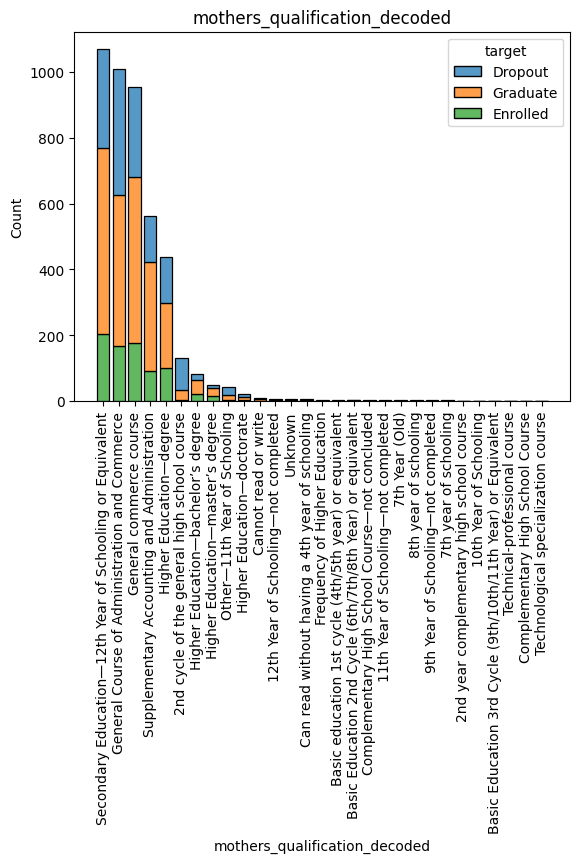


Values for DF column : mothers_qualification_decoded
                                                    Count  Percentage
mothers_qualification_decoded                                        
Secondary Education—12th Year of Schooling or E...   1069       24.16
General Course of Administration and Commerce        1009       22.81
General commerce course                               953       21.54
Supplementary Accounting and Administration           562       12.70
Higher Education—degree                               438        9.90
2nd cycle of the general high school course           130        2.94
Higher Education—bachelor’s degree                     83        1.88
Higher Education—master’s degree                       49        1.11
Other—11th Year of Schooling                           42        0.95
Higher Education—doctorate                             21        0.47
Cannot read or write                                    9        0.20
12th Year of Schooling—not completed

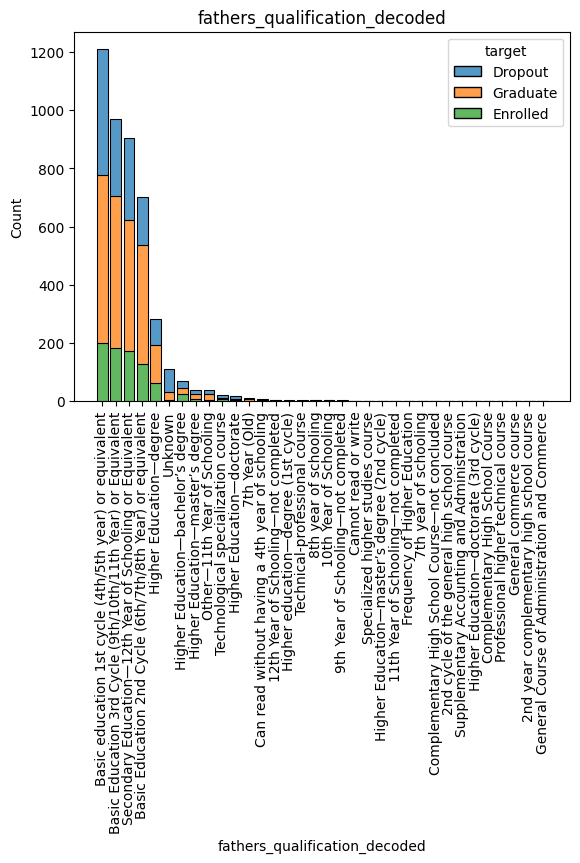


Values for DF column : fathers_qualification_decoded
                                                    Count  Percentage
fathers_qualification_decoded                                        
Basic education 1st cycle (4th/5th year) or equ...   1209       27.33
Basic Education 3rd Cycle (9th/10th/11th Year) ...    968       21.88
Secondary Education—12th Year of Schooling or E...    904       20.43
Basic Education 2nd Cycle (6th/7th/8th Year) or...    702       15.87
Higher Education—degree                               282        6.37
Unknown                                               112        2.53
Higher Education—bachelor’s degree                     68        1.54
Higher Education—master’s degree                       39        0.88
Other—11th Year of Schooling                           38        0.86
Technological specialization course                    20        0.45
Higher Education—doctorate                             18        0.41
7th Year (Old)                      

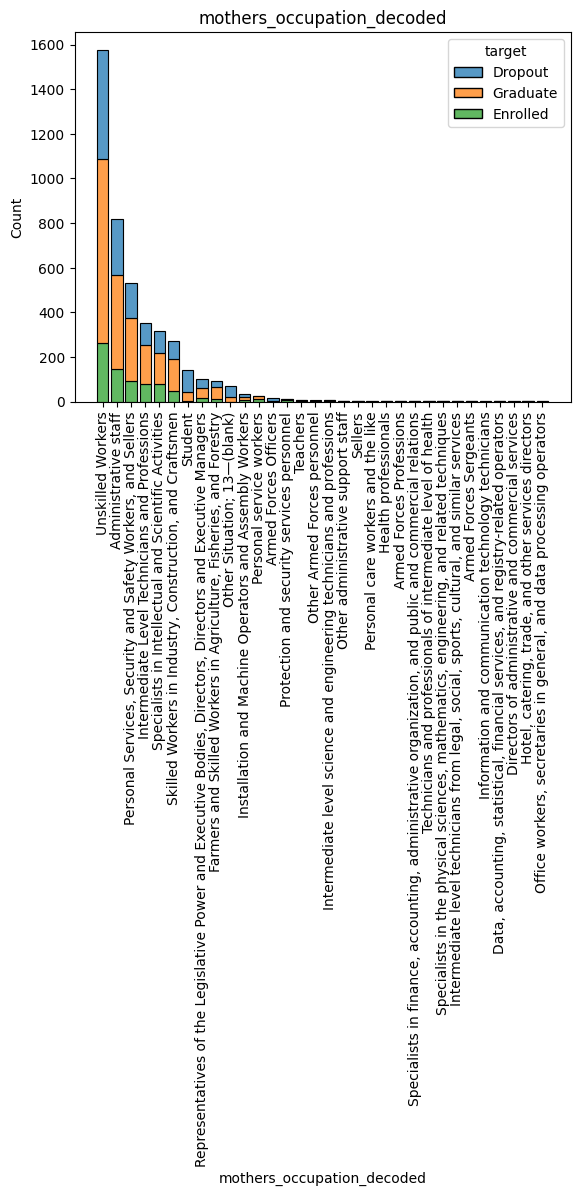


Values for DF column : mothers_occupation_decoded
                                                    Count  Percentage
mothers_occupation_decoded                                           
Unskilled Workers                                    1577       35.65
Administrative staff                                  817       18.47
Personal Services, Security and Safety Workers,...    530       11.98
Intermediate Level Technicians and Professions        351        7.93
Specialists in Intellectual and Scientific Acti...    318        7.19
Skilled Workers in Industry, Construction, and ...    272        6.15
Student                                               144        3.25
Representatives of the Legislative Power and Ex...    102        2.31
Farmers and Skilled Workers in Agriculture, Fis...     91        2.06
Other Situation; 13—(blank)                            70        1.58
Installation and Machine Operators and Assembly...     36        0.81
Personal service workers               

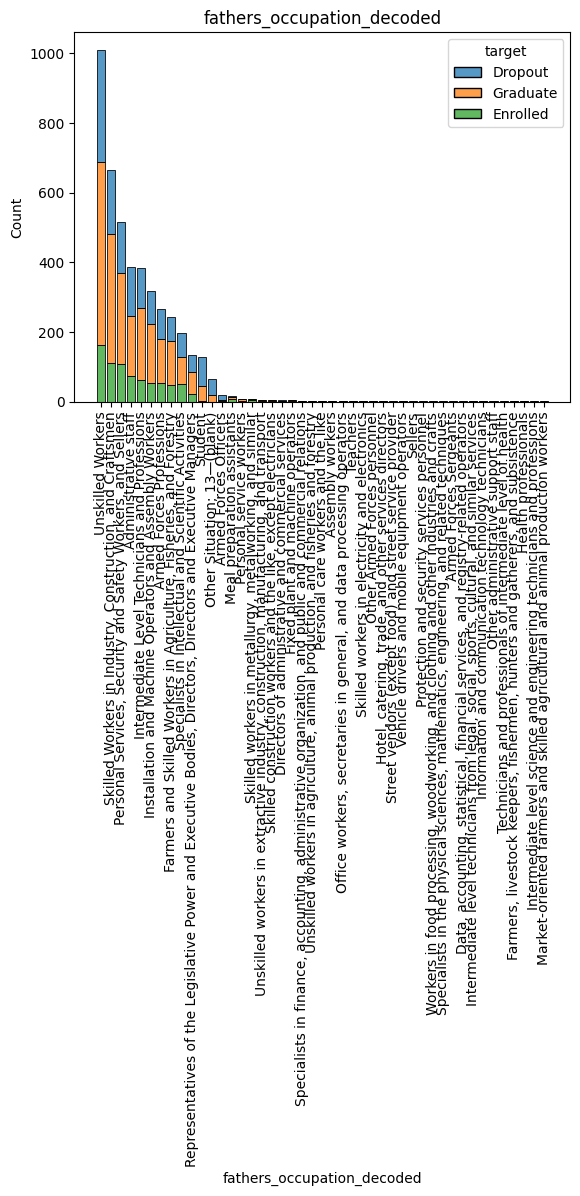


Values for DF column : fathers_occupation_decoded
                                                    Count  Percentage
fathers_occupation_decoded                                           
Unskilled Workers                                    1010       22.84
Skilled Workers in Industry, Construction, and ...    666       15.06
Personal Services, Security and Safety Workers,...    516       11.67
Administrative staff                                  386        8.73
Intermediate Level Technicians and Professions        384        8.68
Installation and Machine Operators and Assembly...    318        7.19
Armed Forces Professions                              266        6.01
Farmers and Skilled Workers in Agriculture, Fis...    242        5.47
Specialists in Intellectual and Scientific Acti...    197        4.45
Representatives of the Legislative Power and Ex...    134        3.03
Student                                               128        2.89
Other Situation; 13—(blank)            

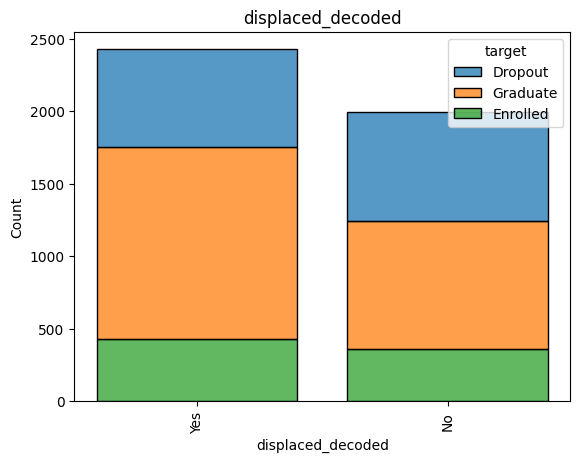


Values for DF column : displaced_decoded
                   Count  Percentage
displaced_decoded                   
Yes                 2426       54.84
No                  1998       45.16


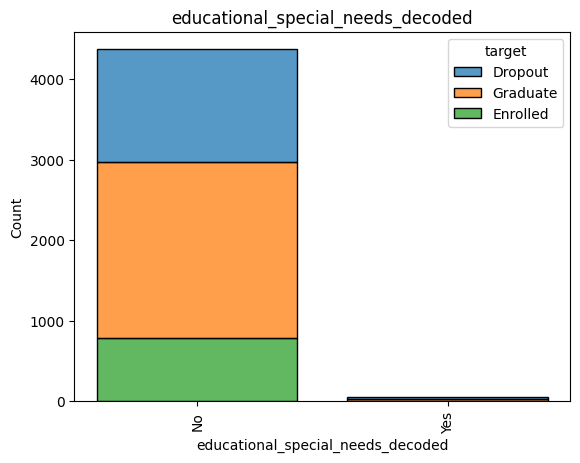


Values for DF column : educational_special_needs_decoded
                                   Count  Percentage
educational_special_needs_decoded                   
No                                  4373       98.85
Yes                                   51        1.15


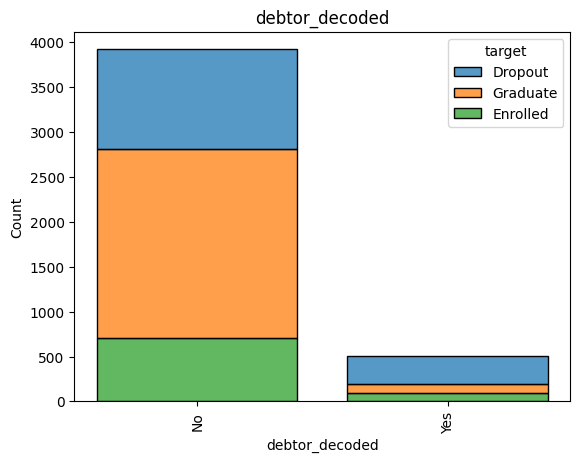


Values for DF column : debtor_decoded
                Count  Percentage
debtor_decoded                   
No               3921       88.63
Yes               503       11.37


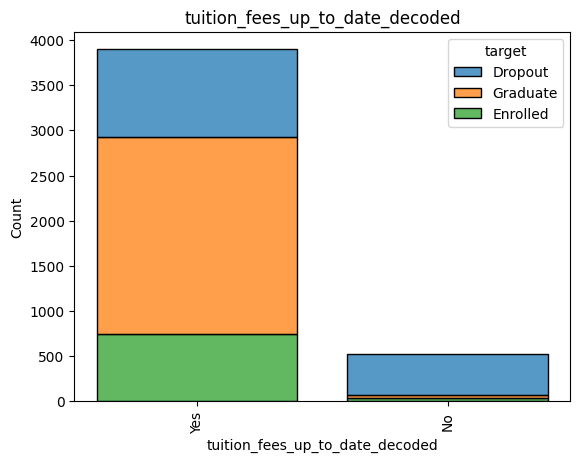


Values for DF column : tuition_fees_up_to_date_decoded
                                 Count  Percentage
tuition_fees_up_to_date_decoded                   
Yes                               3896       88.07
No                                 528       11.93


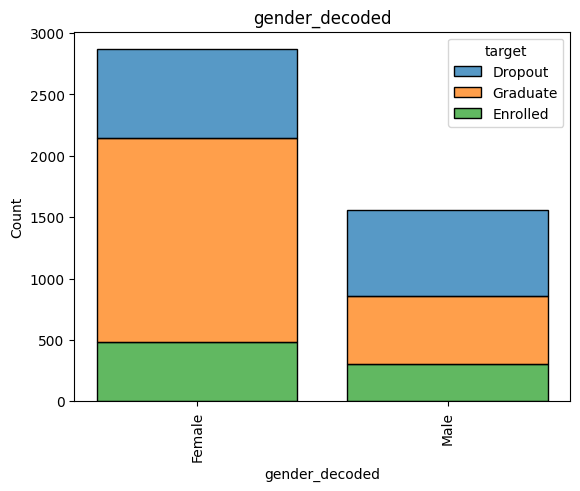


Values for DF column : gender_decoded
                Count  Percentage
gender_decoded                   
Female           2868       64.83
Male             1556       35.17


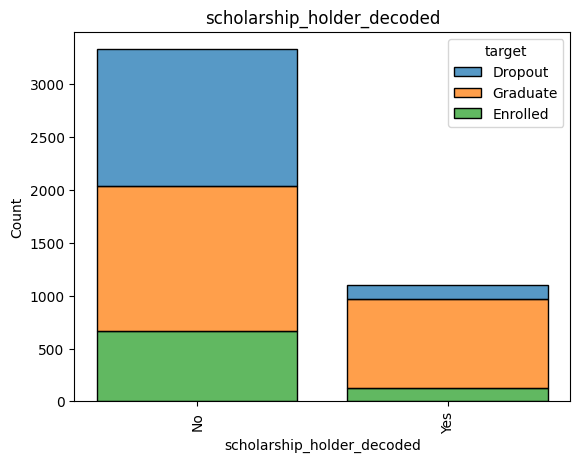


Values for DF column : scholarship_holder_decoded
                            Count  Percentage
scholarship_holder_decoded                   
No                           3325       75.16
Yes                          1099       24.84


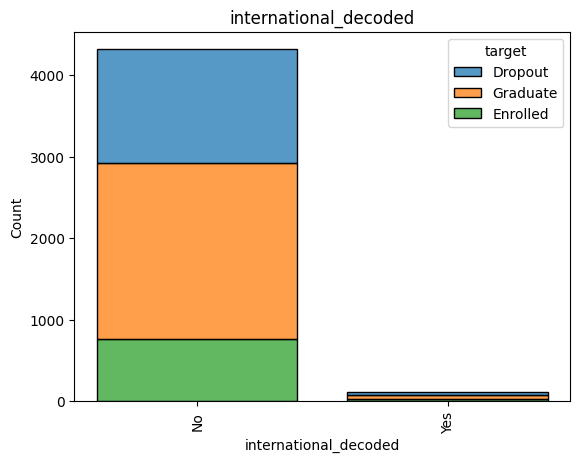


Values for DF column : international_decoded
                       Count  Percentage
international_decoded                   
No                      4314       97.51
Yes                      110        2.49


In [1969]:

#  print value counts for each  column for our decoded categorical variables
categorical_cols_decoded = ['marital_status_decoded', 'application_mode_decoded', 'course_decoded',
       'daytimeevening_attendance_decoded', 'previous_qualification_decoded', 'nationality_decoded',
       'mothers_qualification_decoded', 'fathers_qualification_decoded', 'mothers_occupation_decoded',
       'fathers_occupation_decoded', 'displaced_decoded', 'educational_special_needs_decoded',
       'debtor_decoded', 'tuition_fees_up_to_date_decoded', 'gender_decoded', 
       'scholarship_holder_decoded', 'international_decoded']
       
print('\nCategorical Values by Column:')
for i, col in enumerate(categorical_cols_decoded):

    #decoded_df[col] = decoded_df[col].astype('category')
    order = decoded_df[col].value_counts().index
    decoded_df[col] = pd.Categorical(decoded_df[col], categories=order, ordered=True)


    sns.histplot(data=decoded_df, x=col, hue='target',  multiple="stack", shrink=0.8)
    plt.title(col)
    plt.xticks(rotation=90)
    plt.show()

    decoded_df[col] = decoded_df[col].astype('category')
    val_counts = decoded_df[col].value_counts()
    val_percent = decoded_df[col].value_counts(normalize=True) * 100

    summary = pd.DataFrame({
        'Count': val_counts,
        'Percentage': val_percent.round(2) 
    })
    
    print(f"\nValues for DF column : {col}")
    print(summary)

1.4 What do our Non-Categorical Variables look like

In [1970]:
# Define numerical variables
noncategorical_cols = ['age_at_enrollment', 'application_order',
'curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled',
'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved',
'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations',
'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled',
'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved',
'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations',
'unemployment_rate', 'inflation_rate', 'gdp']

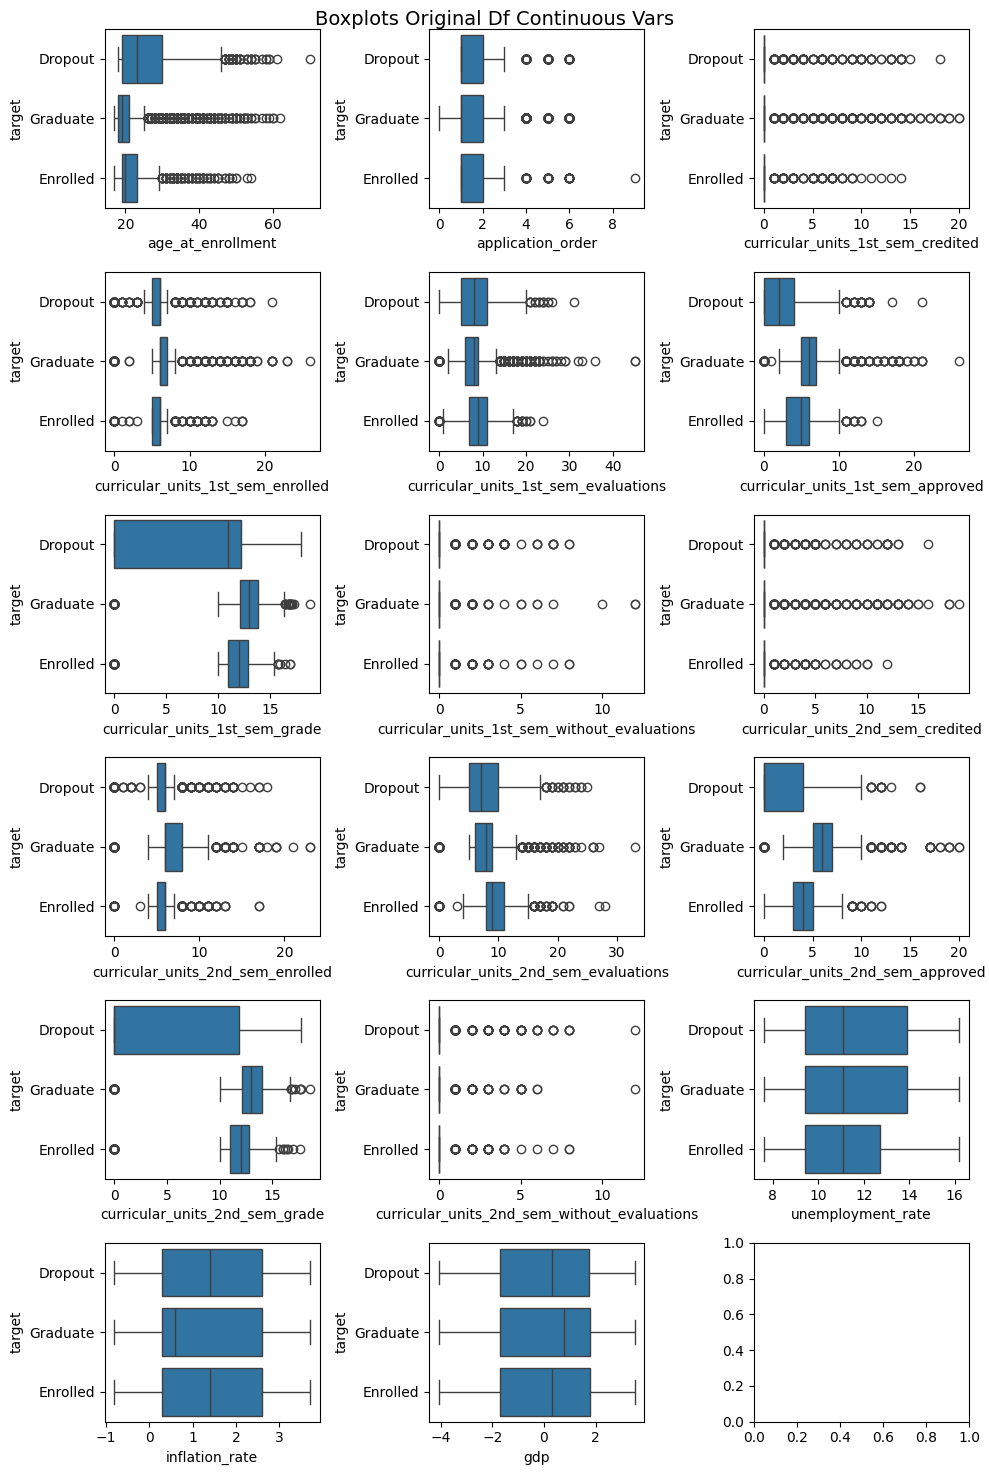

In [1971]:
#Boxplots 
fig, axes = plt.subplots(ncols=3, nrows=6, figsize=(10, 15))
x_counter = 0
y_counter = 0
for i, col in enumerate(noncategorical_cols):
    sns.boxplot(data=decoded_df, x=col, y='target', ax=axes[y_counter, x_counter])
    #axes[i].set_title(f'Countplot for {col}')
    #axes[i].tick_params(axis='x', rotation=45)
    x_counter += 1
    if x_counter == 3:
        x_counter = 0
        y_counter += 1
    if i == len(noncategorical_cols) :
        break

fig.suptitle("Boxplots Original Df Continuous Vars", fontsize=14)
plt.tight_layout()
plt.show()


In [1972]:

# df summary
print('\nSummary metrics for numerical fields | Original Df')
print(decoded_df.describe())

for i, col in enumerate(noncategorical_cols):
        
    top_values = decoded_df.nlargest(5, col)
    
    print(f'\nTop 5 `{col}`', top_values[col])
    Q1 = decoded_df[col].quantile(0.25)
    Q3 = decoded_df[col].quantile(0.75)
    upper_whisker =  Q3 + 1.5 * (Q3 - Q1)
    
    print(f'\nUpper Whisker: `{col}`', upper_whisker)
    count_above_whisker = (decoded_df[col] > upper_whisker).sum()
    print("Count above upper whisker:", count_above_whisker)


Summary metrics for numerical fields | Original Df
       application_order  age_at_enrollment  curricular_units_1st_sem_credited  curricular_units_1st_sem_enrolled  \
count        4424.000000        4424.000000                        4424.000000                        4424.000000   
mean            1.727848          23.265145                           0.709991                           6.270570   
std             1.313793           7.587816                           2.360507                           2.480178   
min             0.000000          17.000000                           0.000000                           0.000000   
25%             1.000000          19.000000                           0.000000                           5.000000   
50%             1.000000          20.000000                           0.000000                           6.000000   
75%             2.000000          25.000000                           0.000000                           7.000000   
max         

#### 1.4.1 Possible Outliers
* One person age 70, where rest between 17-62. We can probably ignore or bin by age
* Possible data entry error in application_order. Only one "9", rest range from 1-6, with IQR between 1-2.


### 1.5 Check for Correlation


 Correlation Heatmap | Extended Df
curricular_units_1st_sem_credited     curricular_units_2nd_sem_credited       0.944811
curricular_units_2nd_sem_credited     curricular_units_1st_sem_credited       0.944811
curricular_units_1st_sem_enrolled     curricular_units_2nd_sem_enrolled       0.942627
curricular_units_2nd_sem_enrolled     curricular_units_1st_sem_enrolled       0.942627
curricular_units_2nd_sem_approved     curricular_units_1st_sem_approved       0.904002
curricular_units_1st_sem_approved     curricular_units_2nd_sem_approved       0.904002
curricular_units_2nd_sem_grade        curricular_units_1st_sem_grade          0.837170
curricular_units_1st_sem_grade        curricular_units_2nd_sem_grade          0.837170
curricular_units_2nd_sem_evaluations  curricular_units_1st_sem_evaluations    0.778863
curricular_units_1st_sem_evaluations  curricular_units_2nd_sem_evaluations    0.778863
curricular_units_1st_sem_credited     curricular_units_1st_sem_enrolled       0.774344
curricu

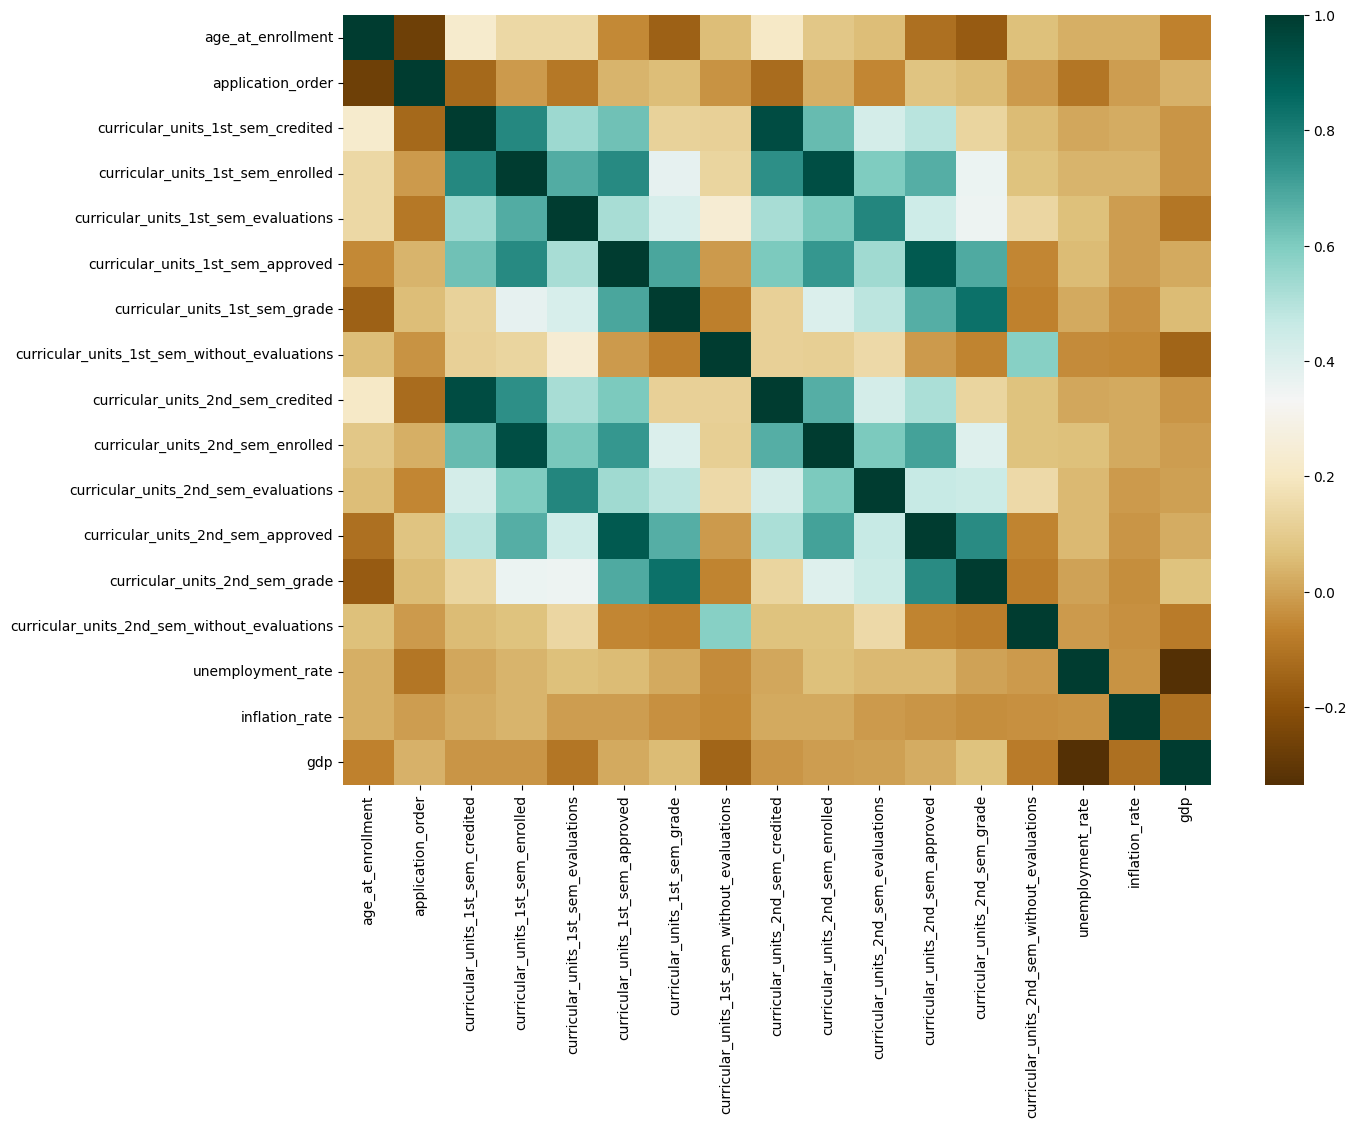

In [1973]:
# correlation 
X = decoded_df[noncategorical_cols]

plt.figure(figsize=(14,10))
corr = X.corr()
sns.heatmap(corr, cmap="BrBG", annot=False)
print('\n Correlation Heatmap | Extended Df')

# print values
corr_abs_sorted = corr.abs().unstack().sort_values(ascending=False)
corr_abs_sorted = corr_abs_sorted[corr_abs_sorted < 1]
print(corr_abs_sorted.head(20))

In [1974]:

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data)

                                         feature         VIF
0              curricular_units_1st_sem_enrolled  170.429084
1              curricular_units_2nd_sem_enrolled  149.019400
2              curricular_units_1st_sem_approved   41.501392
3              curricular_units_2nd_sem_approved   31.982670
4                 curricular_units_1st_sem_grade   28.488251
5                 curricular_units_2nd_sem_grade   26.161148
6           curricular_units_1st_sem_evaluations   19.478674
7           curricular_units_2nd_sem_evaluations   17.203801
8              curricular_units_1st_sem_credited   16.843599
9                              unemployment_rate   13.805167
10             curricular_units_2nd_sem_credited   13.395978
11                             age_at_enrollment    9.735290
12                             application_order    2.797973
13                                inflation_rate    1.806742
14  curricular_units_1st_sem_without_evaluations    1.729472
15  curricular_units_2nd

### 1.6 Check for Imbalance 

Our data shows some imbalance. Ratio is closer if we do not count enrolled.

In [1975]:
val_counts = decoded_df['target'].value_counts()
val_percent = decoded_df['target'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Count': val_counts,
    'Percentage': val_percent.round(2) 
}))


print('Percent dropped out (if enrolled not counted):')
print(1338 / (1338 + 2129) * 100 )


          Count  Percentage
target                     
Graduate   2209       49.93
Dropout    1421       32.12
Enrolled    794       17.95
Percent dropped out (if enrolled not counted):
38.59244303432362


## 2. Feature Engineering

### 2.1 Missing data

The dataset had one missing value for `fathers_occupation_decoded`. A value was provided for `fathers_occupation` but doesn't match any in our dictionary so will convert to "Other". 

Further, 180 of 4424 (~4%) observations have not values entered into any of the 12 1st and 2nd semester fields fields, but had different outcomes/targets. I will drop since this indicates that the student was not in school during the period of interest and records could just add noise to our models.

In [1976]:
print("Missing Values: ")
null_counts = decoded_df.isnull().sum()
null_counts = null_counts[null_counts > 0]
print(null_counts)

# Replace missing values with "Other"
decoded_df['fathers_occupation_decoded'] = decoded_df['fathers_occupation_decoded'].cat.add_categories(['Other'])
decoded_df['fathers_occupation_decoded'] = decoded_df['fathers_occupation_decoded'].fillna('Other')



Missing Values: 
fathers_occupation_decoded    1
dtype: int64


In [1977]:
# drop rows that don't include any of the following
curricular_unit_cols = ['curricular_units_1st_sem_credited', 'curricular_units_1st_sem_enrolled',
'curricular_units_1st_sem_evaluations', 'curricular_units_1st_sem_approved',
'curricular_units_1st_sem_grade', 'curricular_units_1st_sem_without_evaluations',
'curricular_units_2nd_sem_credited', 'curricular_units_2nd_sem_enrolled',
'curricular_units_2nd_sem_evaluations', 'curricular_units_2nd_sem_approved',
'curricular_units_2nd_sem_grade', 'curricular_units_2nd_sem_without_evaluations']

missing_vals_df = (decoded_df[curricular_unit_cols].eq(0).all(axis=1))
print(missing_vals_df.sum())

decoded_engineered_df =  decoded_df[~missing_vals_df]




180


In [1978]:
# drop rows where approved < credited
num_problematic = decoded_engineered_df[
    decoded_engineered_df["curricular_units_1st_sem_credited"] >
    decoded_engineered_df["curricular_units_1st_sem_approved"]
].shape[0]


print(f"\nNum where credited > approved (1st) : {num_problematic}")

rows_to_keep = decoded_engineered_df["curricular_units_1st_sem_credited"] <= decoded_engineered_df["curricular_units_1st_sem_approved"]
decoded_engineered_df = decoded_engineered_df[rows_to_keep].copy()

num_problematic = decoded_engineered_df[
    decoded_engineered_df["curricular_units_2nd_sem_credited"] >
    decoded_engineered_df["curricular_units_2nd_sem_approved"]
].shape[0]

print(f"\nNum where credited > approved (2nd) : {num_problematic}")

rows_to_keep = decoded_engineered_df["curricular_units_2nd_sem_credited"] <= decoded_engineered_df["curricular_units_2nd_sem_approved"]
decoded_engineered_df = decoded_engineered_df[rows_to_keep].copy()

print(decoded_engineered_df.shape[0])


Num where credited > approved (1st) : 6

Num where credited > approved (2nd) : 5
4233


A handful of rows (11 total) had credited > approved, but it seems questionable that you can get credit w.out passing class.

In [1979]:
# combine 1st and 2nd semester variables

decoded_engineered_df["total_credited"] = decoded_engineered_df["curricular_units_1st_sem_credited"] + decoded_engineered_df["curricular_units_2nd_sem_credited"]
decoded_engineered_df["total_enrolled"] = decoded_engineered_df["curricular_units_1st_sem_enrolled"] + decoded_engineered_df["curricular_units_2nd_sem_enrolled"]
decoded_engineered_df["total_evaluations"] = decoded_engineered_df["curricular_units_1st_sem_evaluations"] + decoded_engineered_df["curricular_units_2nd_sem_evaluations"]
decoded_engineered_df["total_approved"] = decoded_engineered_df["curricular_units_1st_sem_approved"] + decoded_engineered_df["curricular_units_2nd_sem_approved"]
decoded_engineered_df["total_wout_evaluations"] = decoded_engineered_df["curricular_units_1st_sem_without_evaluations"] + decoded_engineered_df["curricular_units_2nd_sem_without_evaluations"]

g1 = decoded_engineered_df["curricular_units_1st_sem_grade"]
g2 = decoded_engineered_df["curricular_units_2nd_sem_grade"]
n1 = decoded_engineered_df["curricular_units_1st_sem_evaluations"]  
n2 = decoded_engineered_df["curricular_units_2nd_sem_evaluations"]

decoded_engineered_df["weighted_avg_grade"] = (
    (g1 * n1 + g2 * n2) / (n1 + n2).replace(0, np.nan)
)

#decoded_engineered_df["total_grade_sum"] = g1 * n1 + g2 * n2

# fill n/a with 0 for weighted_avg_grade
decoded_engineered_df["weighted_avg_grade"] = decoded_engineered_df["weighted_avg_grade"].fillna(0)



### 2.2 Dropping Features

We will drop columns that are highly correlated. For example 1st and 2nd enrolled

In [ ]:
# drop original curricular fields 
decoded_engineered_df.drop(columns=curricular_unit_cols, inplace=True)


# copy
decoded_engineered_df['y'] = decoded_df['target'].replace({'Graduate': 0, 'Dropout': 1, 'Enrolled': 2})
decoded_engineered_df['y'] = decoded_engineered_df['y'].astype('category')
decoded_engineered_df.drop(columns=['target'], inplace=True)


# drop original categorical encoded fields, as we will be recoding
if "target" in categorical_cols_orginal:
    categorical_cols.remove("target")
decoded_engineered_df.drop(columns=categorical_cols_orginal, inplace=True)




<class 'pandas.core.frame.DataFrame'>
Index: 4233 entries, 1 to 4423
Data columns (total 29 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   application_order                  4233 non-null   int64   
 1   age_at_enrollment                  4233 non-null   int64   
 2   unemployment_rate                  4233 non-null   float64 
 3   inflation_rate                     4233 non-null   float64 
 4   gdp                                4233 non-null   float64 
 5   marital_status_decoded             4233 non-null   category
 6   application_mode_decoded           4233 non-null   category
 7   course_decoded                     4233 non-null   category
 8   daytimeevening_attendance_decoded  4233 non-null   category
 9   previous_qualification_decoded     4233 non-null   category
 10  nationality_decoded                4233 non-null   category
 11  mothers_qualification_decoded      4233 non-null

<positron-console-cell-1980>:6: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`


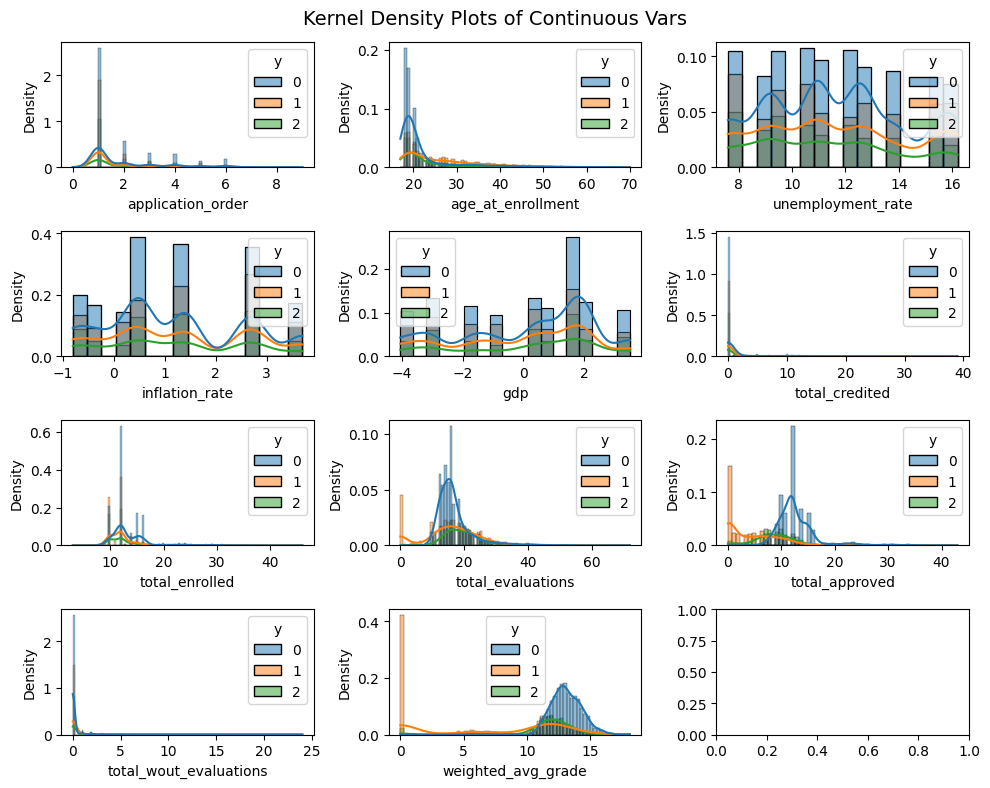


Summary metrics for numerical fields | Original Df
       application_order  age_at_enrollment  unemployment_rate  inflation_rate          gdp  total_credited  total_enrolled  \
count        4233.000000        4233.000000        4233.000000     4233.000000  4233.000000     4233.000000     4233.000000   
mean            1.735412          23.368533          11.561540        1.229530     0.021191        1.271202       13.011576   
std             1.322667           7.649473           2.661932        1.377656     2.273148        4.231059        3.874278   
min             0.000000          17.000000           7.600000       -0.800000    -4.060000        0.000000        3.000000   
25%             1.000000          19.000000           9.400000        0.300000    -1.700000        0.000000       11.000000   
50%             1.000000          20.000000          11.100000        1.400000     0.320000        0.000000       12.000000   
75%             2.000000          25.000000          13.900

In [ ]:
numeric_cols = decoded_engineered_df.select_dtypes(include=['int64', 'float64']).columns

#Boxplots 
fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(10, 8))
x_counter = 0
y_counter = 0
for i, col in enumerate(numeric_cols):
    sns.histplot(data=decoded_engineered_df, x=col, hue='y', kde=True, stat="density", ax=axes[y_counter, x_counter])
    x_counter += 1
    if x_counter == 3:
        x_counter = 0
        y_counter += 1
    if i == len(numeric_cols) :
        break

fig.suptitle("Kernel Density Plots of Continuous Vars", fontsize=14)
plt.tight_layout()
plt.show()


print('\nSummary metrics for numerical fields | Original Df')
print(decoded_engineered_df.describe())

In [1982]:
# calculate correlation on new params
X = decoded_engineered_df[numeric_cols]
corr = X.corr()
print('\n Correlation Heatmap | Extended Df')

# print values
corr_abs_sorted = corr.abs().unstack().sort_values(ascending=False)
corr_abs_sorted = corr_abs_sorted[corr_abs_sorted < 1]
print(corr_abs_sorted.head(20))



 Correlation Heatmap | Extended Df
total_enrolled      total_credited        0.845594
total_credited      total_enrolled        0.845594
total_approved      total_enrolled        0.728082
total_enrolled      total_approved        0.728082
total_approved      weighted_avg_grade    0.714183
weighted_avg_grade  total_approved        0.714183
total_credited      total_approved        0.596704
total_approved      total_credited        0.596704
total_enrolled      total_evaluations     0.572466
total_evaluations   total_enrolled        0.572466
total_credited      total_evaluations     0.549358
total_evaluations   total_credited        0.549358
                    total_approved        0.464565
total_approved      total_evaluations     0.464565
gdp                 unemployment_rate     0.339971
unemployment_rate   gdp                   0.339971
total_evaluations   weighted_avg_grade    0.337554
weighted_avg_grade  total_evaluations     0.337554
age_at_enrollment   application_order     0.27

In [1983]:

# Calculate VIF for each feature
vif_data = pd.DataFrame()
vif_data["feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif_data = vif_data.sort_values(by="VIF", ascending=False).reset_index(drop=True)
print(vif_data)


                   feature        VIF
0           total_enrolled  46.898824
1           total_approved  24.367550
2       weighted_avg_grade  24.002868
3        unemployment_rate  19.025987
4        total_evaluations  13.227788
5        age_at_enrollment  10.084190
6           total_credited   3.798139
7        application_order   2.993781
8           inflation_rate   1.835172
9   total_wout_evaluations   1.174381
10                     gdp   1.142148



### 2.3 Grouping categories

The following section groups similar categories together to assist with dimensionality reduction.

In [1984]:
combine_map = {
    "Married": "Married",
    "Widower": "Other",
    "Divorced": "Other",
    "Common-law marriage": "Married",
    "Legally separated": "Other",
}

# Apply the mapping to create a new column
decoded_engineered_df["marital_status_decoded"] = decoded_engineered_df["marital_status_decoded"].replace(combine_map)

print(decoded_engineered_df["marital_status_decoded"].unique())


['Single', 'Married', 'Other']
Categories (3, object): ['Single' < 'Married' < 'Other']


<positron-console-cell-1984>:10: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [1985]:
col = "application_mode_decoded"

combine_map = {
    "Change in course": "Change in institution/course",
    "Transfer": "Change in institution/course",
    "Change in institution/course": "Change in institution/course",
    "International student (bachelor)": "International student",
    "Change in institution/course (International)": "International student",
    "1st phase—general contingent": "1st phase",
    "1st phase—special contingent (Madeira Island)": "1st phase",
    "1st phase—special contingent (Azores Island)": "1st phase",
    "2nd phase—general contingent": "2nd phase",
    "3rd phase—general contingent": "3rd phase",
    "Technological specialization diploma holders": "Specialized diploma",
    "Short cycle diploma holders":  "Specialized diploma"
}
decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)

# group all others with less than 5% of samples
val_counts = decoded_engineered_df[col].value_counts()
val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_percent[val_percent < 2].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))



                                    Count
application_mode_decoded                 
1st phase                        0.387668
2nd phase                        0.199150
Over 23 years old                0.182613
Change in institution/course     0.101583
Specialized diploma              0.057170
Holders of other higher courses  0.032129
3rd phase                        0.028821
Other                            0.010867


<positron-console-cell-1985>:17: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-1985>:23: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [1986]:
# Group 
col = "course_decoded"

combine_map = {
    "Management (evening attendance)": "Management",
    "Social Service (evening attendance)": "Social Service",
    "Basic Education": "Other",
    "Biofuel Production Technologies": "Other",
    "Communication Design": "Design and Multimedia",
    "Animation and Multimedia Design": "Design and Multimedia"
}

decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

                                         Count
course_decoded                                
Nursing                               0.180959
Management                            0.152847
Social Service                        0.132766
Veterinary Nursing                    0.079613
Journalism and Communication          0.078195
Advertising and Marketing Management  0.063312
Design and Multimedia                 0.061658
Tourism                               0.059060
Agronomy                              0.049610
Other                                 0.048193
Informatics Engineering               0.040161
Equiniculture                         0.033310
Oral Hygiene                          0.020317


<positron-console-cell-1986>:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [1987]:
col = "previous_qualification_decoded"

combine_map = {
    "Higher education—degree": "Higher education" ,
    "Higher education—bachelor’s degree": "Higher education",
    "Higher education—degree (1st cycle)": "Higher education",
    "Higher education—master’s degree": "Higher education",
    "Higher education—master’s degree (1st cycle)": "Higher education",
    "Higher education—master’s degree (2nd cycle)": "Higher education" ,
    "Higher education—doctorate": "Higher education" ,
    "Frequency of Higher Education": "Higher education",
    "Technological specialization course": "Specialized course",
    "Professional higher technical course": "Specialized course",
}

decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)
    
val_counts = decoded_engineered_df[col].value_counts()
val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_counts[val_counts <= 100].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))



                                                       Count
previous_qualification_decoded                              
Secondary education                                 0.837231
Specialized course                                  0.058351
Higher education                                    0.047248
Basic education 3rd cycle (9th/10th/11th year) ...  0.037562
Other                                               0.019608


<positron-console-cell-1987>:16: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-1987>:21: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [1988]:
col = "nationality_decoded"
 
val_counts = decoded_engineered_df[col].value_counts()
val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_counts[val_percent < 2].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))



                        Count
nationality_decoded          
Portuguese           0.376093
Angolan              0.199150
Santomean            0.182613
Brazilian            0.070399
Other                0.061895
Romanian             0.048901
Italian              0.032129
Cape Verdean         0.028821


<positron-console-cell-1988>:6: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [1989]:
col = "mothers_qualification_decoded"

combine_map = {
    "Higher Education—degree": "Higher education" ,
    "Higher Education—bachelor’s degree": "Higher education",
    "Higher Education—degree (1st cycle)": "Higher education",
    "Higher education—degree (1st cycle)": "Higher education",
    "Higher Education—master’s degree": "Higher education",
    "Higher Education—master’s degree (1st cycle)": "Higher education",
    "Higher Education—master’s degree (2nd cycle)": "Higher education" ,
    "Higher Education—doctorate": "Higher education",
    "Higher Education—doctorate (3rd cycle)": "Higher education",
    "Frequency of Higher Education": "Higher education",
    "2nd cycle of the general high school course": "Some High School",
    "Other—11th Year of Schooling": "Some High School",
    "12th Year of Schooling—not completed": "Some High School",
    "11th Year of Schooling—not completed": "Some High School",
    "10th Year of Schooling": "Some High School",
    "Complementary High School Course—not concluded": "Some High School",
    "2nd year complementary high school course": "Some High School",
    "Complementary High School Course": "Some High School",
    "9th Year of Schooling—not completed": "Some High School",
    "7th Year (Old)": "Basic education",
    "7th year of schooling": "Basic education",
    "8th year of schooling": "Basic education",
    "General Course of Administration and Commerce": "Specialized course",
    "General commerce course": "Specialized course",
    "Technological specialization course": "Specialized course",
    "Technical-professional course": "Specialized course",
    "Professional higher technical course": "Specialized course",
    "Specialized higher studies course": "Specialized course",
    "Supplementary Accounting and Administration": "Specialized course",
    "Can read without having a 4th year of schooling": "Basic education or less",
    "Cannot read or write": "Basic education or less",
    "Secondary Education—12th Year of Schooling or Equivalent": "Secondary Education"
}

decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)
decoded_engineered_df[col] = decoded_engineered_df[col].apply(
    lambda x: "Basic education or less" if "basic education" in str(x).lower() else x
)

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

col = "fathers_qualification_decoded"
decoded_engineered_df[col] = decoded_engineered_df[col].replace(combine_map)
decoded_engineered_df[col] = decoded_engineered_df[col].apply(
    lambda x: "Basic education or less" if "basic education" in str(x).lower() else x
)

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))


                                  Count
mothers_qualification_decoded          
Specialized course             0.575242
Secondary Education            0.241673
Higher education               0.130876
Some High School               0.042996
Basic education or less        0.007560
Unknown                        0.001654
                                  Count
fathers_qualification_decoded          
Basic education or less        0.661233
Secondary Education            0.204111
Higher education               0.090952
Unknown                        0.025278
Some High School               0.011812
Specialized course             0.006615


<positron-console-cell-1989>:38: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-1989>:46: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


In [1990]:
col = "mothers_occupation_decoded"

val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_percent[val_percent < 5].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

col = "fathers_occupation_decoded"

val_percent = decoded_engineered_df[col].value_counts(normalize=True) * 100
to_group = val_percent[val_percent < 5].index
decoded_engineered_df[col] = decoded_engineered_df[col].replace(to_group, "Other")

print(pd.DataFrame({'Count': decoded_engineered_df[col].value_counts(normalize=True) }))

                                                       Count
mothers_occupation_decoded                                  
Unskilled Workers                                   0.357193
Administrative staff                                0.185448
Other                                               0.127333
Personal Services, Security and Safety Workers,...  0.119064
Intermediate Level Technicians and Professions      0.080321
Specialists in Intellectual and Scientific Acti...  0.069218
Skilled Workers in Industry, Construction, and ...  0.061422
                                                       Count
fathers_occupation_decoded                                  
Unskilled Workers                                   0.227498
Skilled Workers in Industry, Construction, and ...  0.151429
Other                                               0.141743
Personal Services, Security and Safety Workers,...  0.117647
Administrative staff                                0.088590
Intermediate Level Techn

<positron-console-cell-1990>:5: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
<positron-console-cell-1990>:13: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.


<positron-console-cell-1991>:25: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.


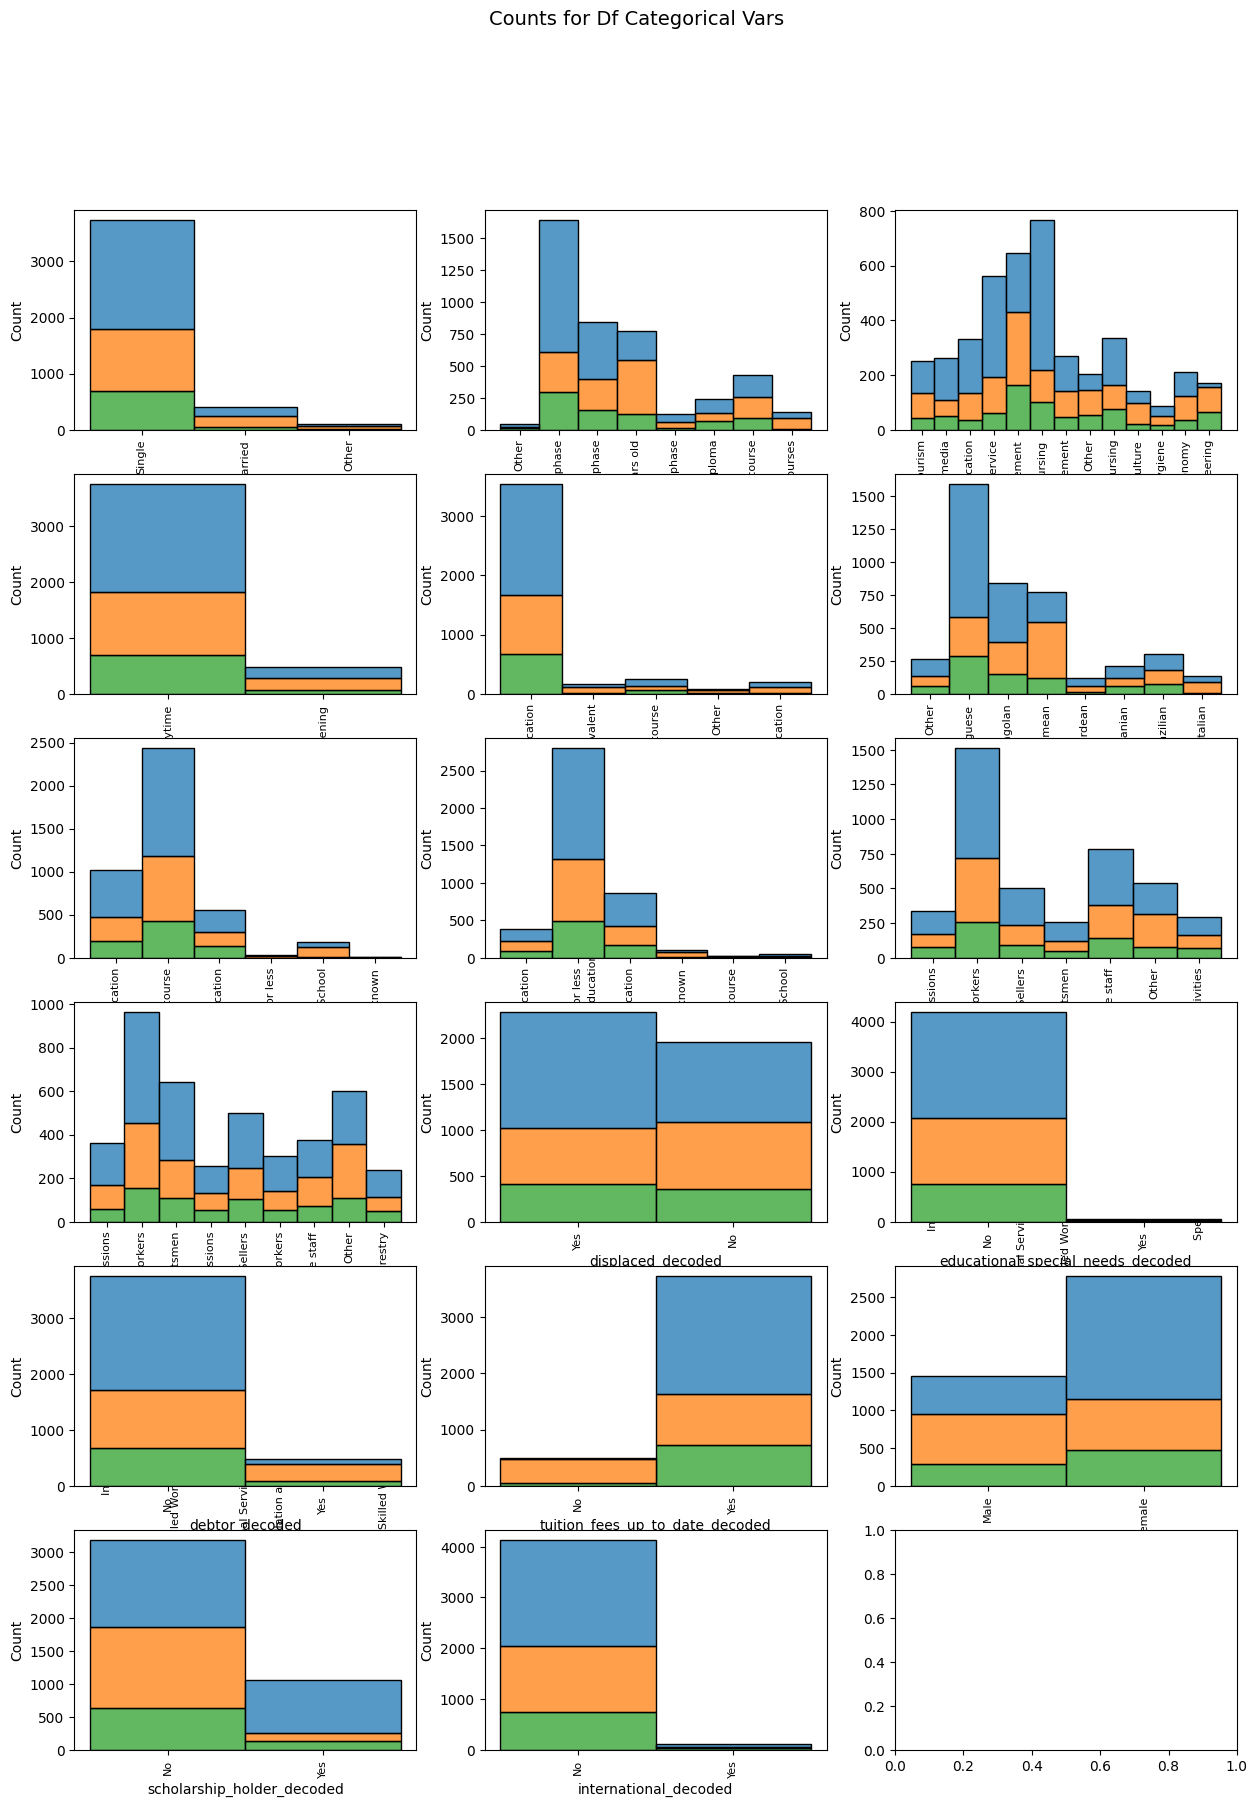

In [1991]:
# print facetted barplots for categorical values

max_cols = 3
max_rows = 6
fig_ori_dist, axes = plt.subplots(ncols=max_cols, nrows=max_rows, figsize=(15, 20))
categorical_cols_orginal.append('target')

x_counter = 0
y_counter = 0
for i, col in enumerate(categorical_cols_decoded):

    decoded_engineered_df[col] = decoded_engineered_df[col].astype('category')

    sns.histplot(data=decoded_engineered_df, x=decoded_engineered_df[col].astype(str), hue='y', ax=axes[y_counter, x_counter], multiple="stack")
    axes[y_counter, x_counter].tick_params(axis='x', labelsize=8, labelrotation=90)
    axes[y_counter, x_counter].get_legend().remove()
    x_counter += 1
    if x_counter == max_cols:
        x_counter = 0
        y_counter += 1
    if i == len(categorical_cols_decoded) :
        break

fig_ori_dist.suptitle("Counts for Df Categorical Vars", fontsize=14)
plt.tight_layout(pad=1)
plt.show()



### 2.4 What about Enrolled

18% of our observations are marked as in "enrolled", which is the student's current state. Keeping this class might make it harder to find the signals for dropout as students my drop out later. Therfore we will drop it, even as that means shrinking our dataset. We should watch out for curse of dimensionality and may need to apply Dimensionality reduction techniques.

In [1992]:
# dropped enrolled students to reduce possible noise
simplified_df = decoded_engineered_df[decoded_engineered_df["y"] != 2]
simplified_df['y'] = simplified_df['y'].cat.remove_categories([2])

val_counts = simplified_df['y'].value_counts()
val_percent = simplified_df['y'].value_counts(normalize=True) * 100

print(pd.DataFrame({
    'Count': val_counts,
    'Percentage': val_percent.round(2) 
}))

   Count  Percentage
y                   
0   2130       61.42
1   1338       38.58


<positron-console-cell-1992>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy


## 3. Model Training

### 3.0 - Base Model (Decision Tree)

In [2013]:
# split our data
X = simplified_df.drop(['y'], axis=1)
y = simplified_df['y']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=13, stratify=y)

categorical_cols = categorical_cols_decoded

# define our preprocessor
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
], remainder='drop')

# Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', DecisionTreeClassifier(random_state=13))
])

# Fit
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)


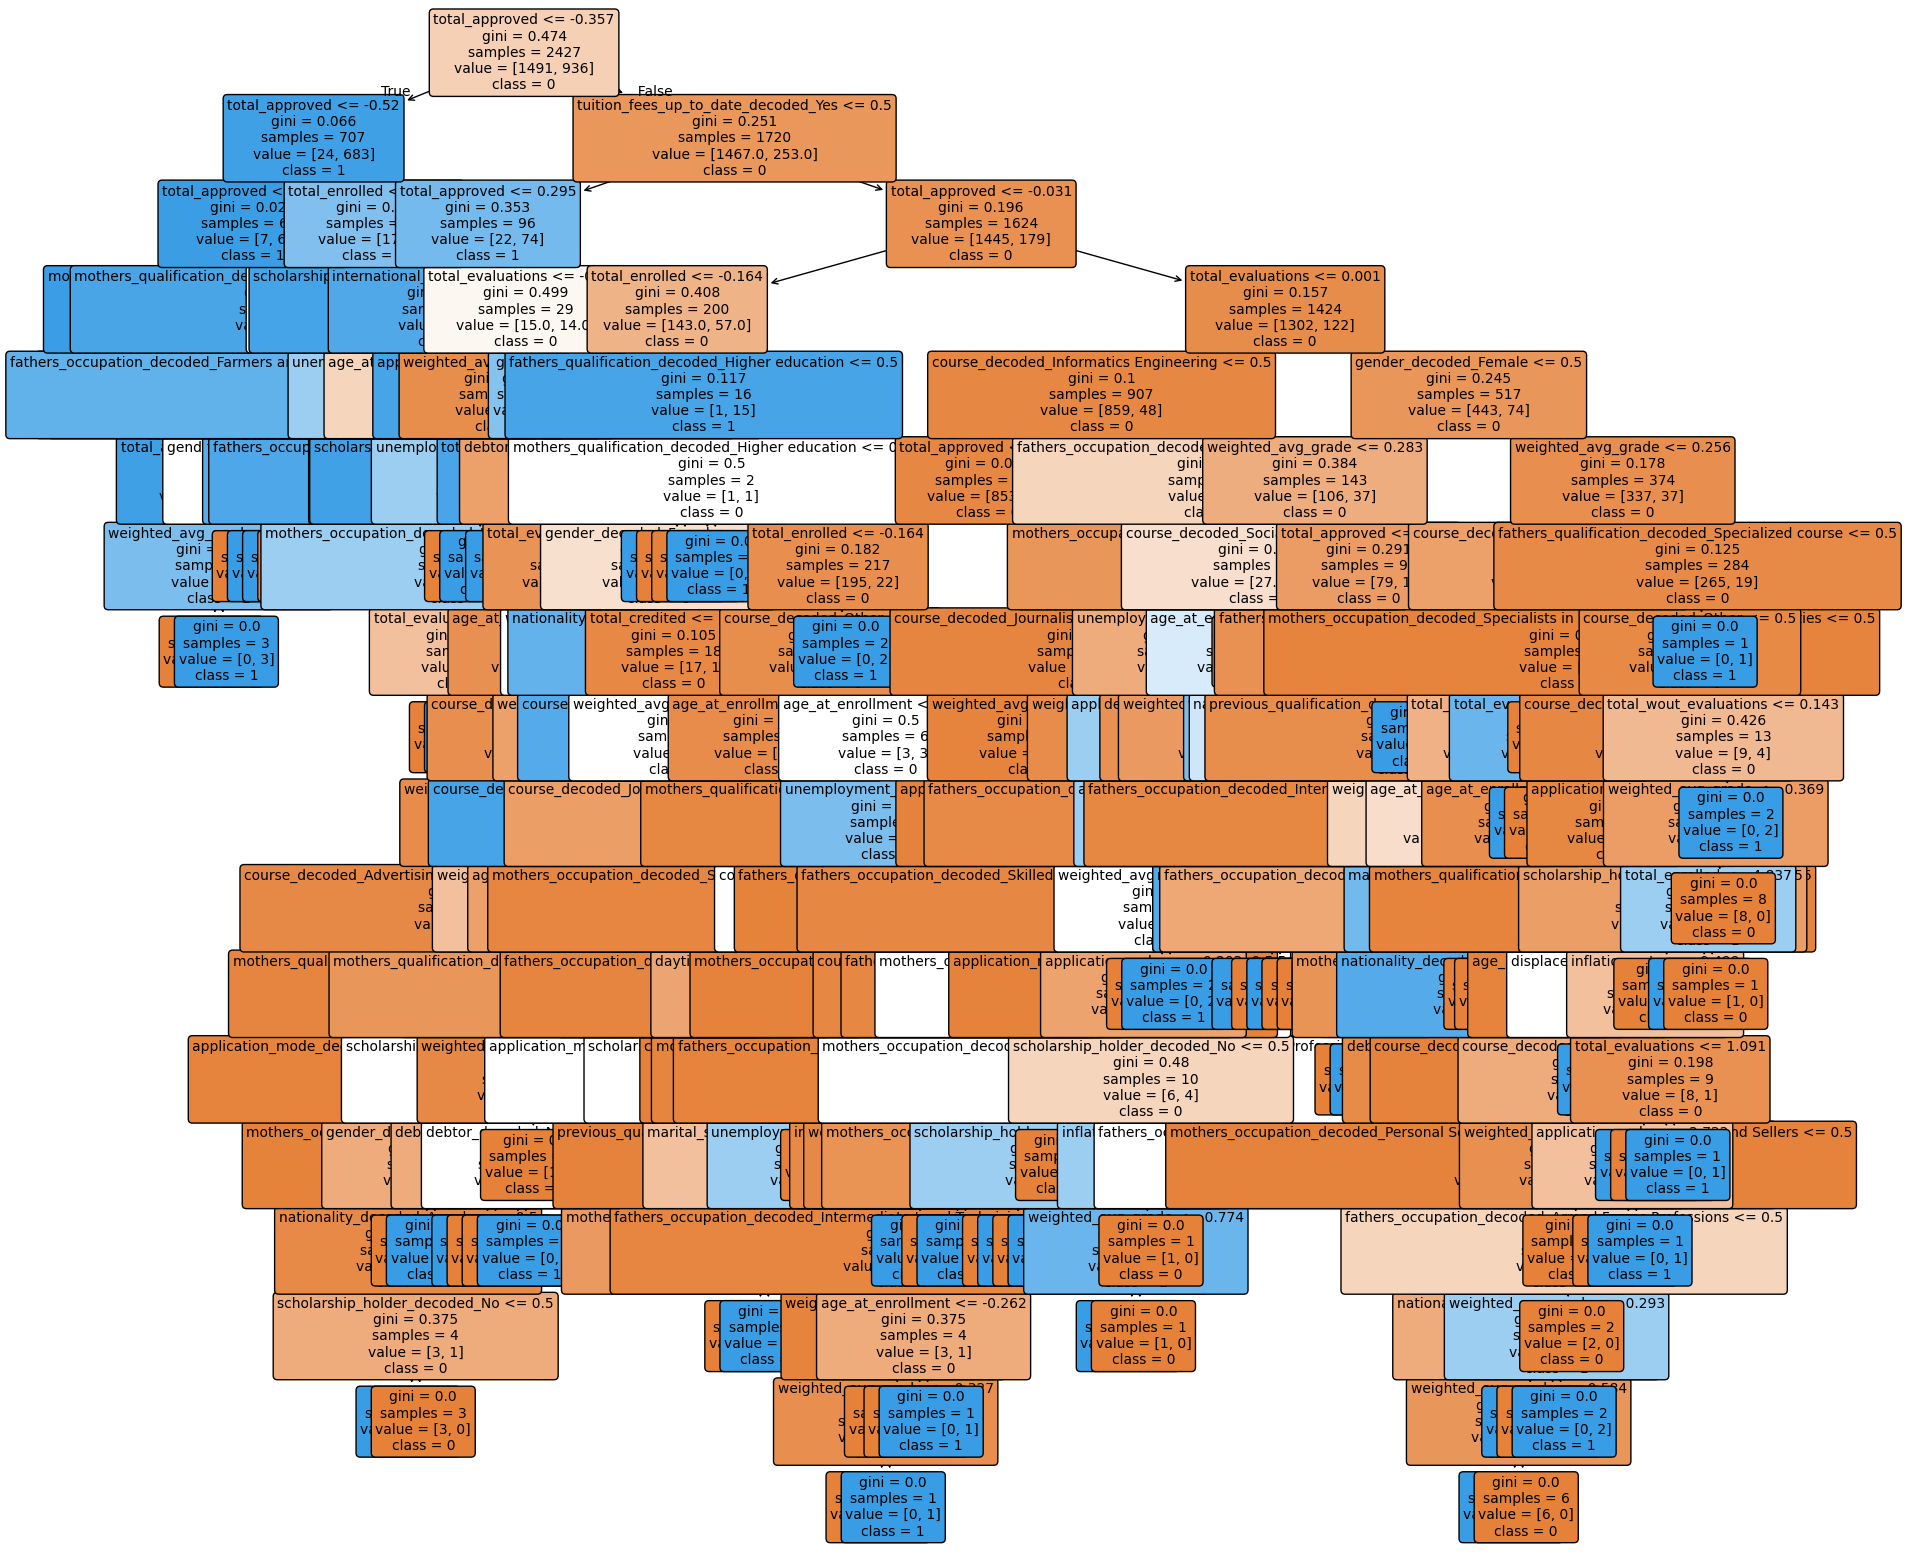

In [1994]:


categorical_features = pipeline.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .get_feature_names_out(categorical_cols)

plt.figure(figsize=(20,20))
plot_tree(
    pipeline.named_steps['classifier'],
    feature_names=list(numeric_cols) + list(categorical_features),
    class_names=pipeline.named_steps['classifier'].classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()

Best max_depth: 7


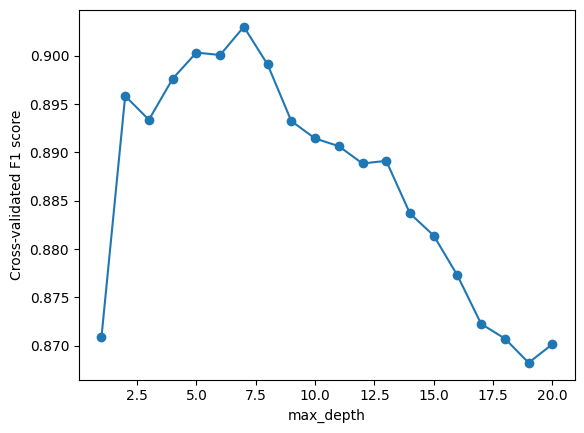

In [1995]:
max_depths = range(1, 21)
cv_scores = []

for depth in max_depths:
   
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=depth, random_state=13))
    ])

    scores = cross_val_score(pipeline, X_train, y_train, cv=5, scoring='f1_macro') 
    cv_scores.append(np.mean(scores))

# Find the best depth
best_depth = max_depths[np.argmax(cv_scores)]
print("Best max_depth:", best_depth)

# Optional: plot performance vs depth
import matplotlib.pyplot as plt

plt.plot(max_depths, cv_scores, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Cross-validated F1 score')
plt.show()

Train score: 0.9447878038730944


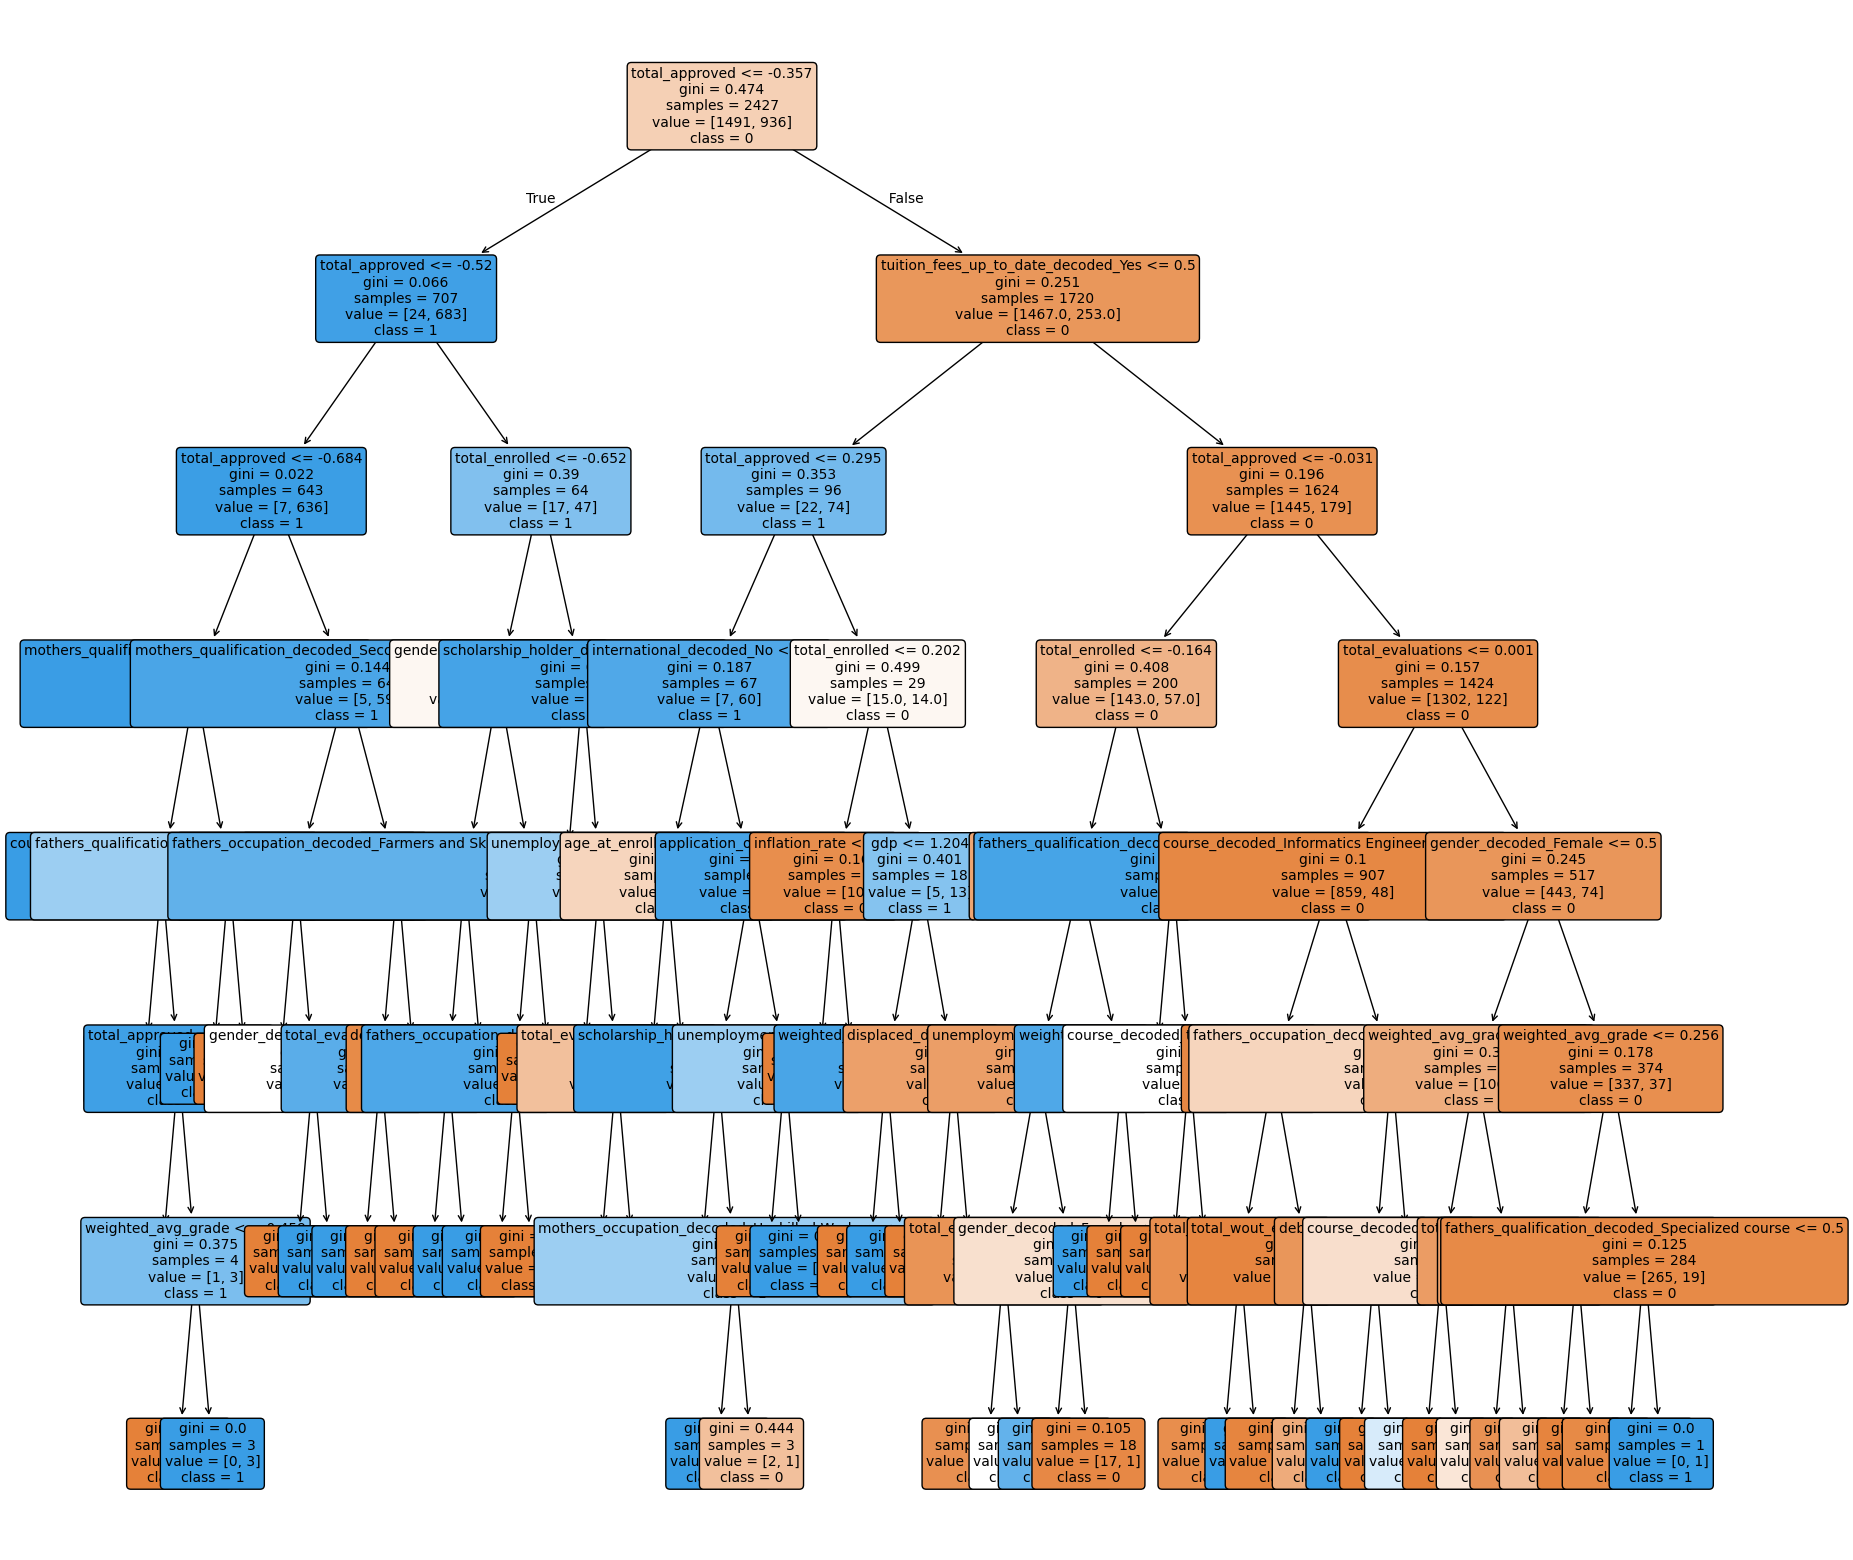

In [1996]:
dt_model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', DecisionTreeClassifier(max_depth=7, random_state=13))
    ])
dt_model.fit(X_train, y_train)
print("Train score:", dt_model.score(X_train, y_train))


categorical_features = dt_model.named_steps['preprocessor']\
                .named_transformers_['cat']\
                .get_feature_names_out(categorical_cols)

plt.figure(figsize=(20,20))
plot_tree(
    dt_model.named_steps['classifier'],
    feature_names=list(numeric_cols) + list(categorical_features),
    class_names=dt_model.named_steps['classifier'].classes_.astype(str),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.show()


In [1997]:
# Evaluation Metrics
eval_df = pd.DataFrame(columns=['model_name', 'accuracy', 'recall_no', 'recall_yes', 'f1_no', 'f1_yes', 'auc', 'auprc'])

def evaluate_model(model, model_name):
    global X_test, y_test, eval_df

    print(f'\n{model_name}\n'),

    # print matrix
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    print(f'Confusion Matrix for {model_name}\n', confusion_matrix(y_test, y_pred))
    print(f"\nClassification Report for {model_name}:\n", classification_report(y_test, y_pred))

    
    # print top ten
    preprocessor = model.named_steps['preprocessor']
    clf = model.named_steps['classifier']

    features = pd.DataFrame(
        clf.feature_importances_,
        index=preprocessor.get_feature_names_out(),
        columns=['importance']
    )

    print(f'\nTop Features \n', features.sort_values(by='importance', ascending=False).head(20))


    # Add metrics to our eval dataframe
    report = classification_report(y_test, y_pred, output_dict=True)
    results = pd.DataFrame([{
        'model_name': model_name,
        'accuracy': report['accuracy'],
        'recall_no': report['0']['recall'],
        'recall_yes': report['1']['recall'],
        'f1_no': report['0']['f1-score'],
        'f1_yes': report['1']['f1-score'],
        'auc': roc_auc_score(y_test, y_proba),
        'auprc': average_precision_score(y_test, y_proba)
    }])

    return pd.concat([eval_df, results], ignore_index=True)



In [1998]:
eval_df = evaluate_model(dt_model, model_name="Decision Tree")


Decision Tree

Confusion Matrix for Decision Tree
 [[607  32]
 [ 88 314]]

Classification Report for Decision Tree:
               precision    recall  f1-score   support

           0       0.87      0.95      0.91       639
           1       0.91      0.78      0.84       402

    accuracy                           0.88      1041
   macro avg       0.89      0.87      0.87      1041
weighted avg       0.89      0.88      0.88      1041


Top Features 
                                                     importance
num__total_approved                                   0.756186
cat__tuition_fees_up_to_date_decoded_Yes              0.084700
num__total_enrolled                                   0.032360
cat__gender_decoded_Female                            0.016698
num__weighted_avg_grade                               0.012272
num__total_evaluations                                0.011496
cat__course_decoded_Other                             0.010217
cat__course_decoded_Social Service 

<positron-console-cell-1998>:42: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.


### 3.1 Random Forest

Chose Random Forest on account of its ability to 

In [2014]:
# degine preprocessor for rf
preprocessor2 = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
            ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
        ]), categorical_cols),
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
            ('standardizer', StandardScaler())
        ]), numeric_cols)
    ], remainder='drop'
)

# Build base model
rf0_model = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('classifier', RandomForestClassifier(
        n_estimators=300,
        random_state=13,
        oob_score=True,
        n_jobs=-1
    ))
])

rf0_model.fit(X_train, y_train)

scores = cross_val_score(rf0_model, X_train, y_train, cv=10, scoring='f1_macro')
print("Mean F1-macro CV score:", scores.mean())

eval_df = evaluate_model(rf0_model, model_name="RF0")

Mean F1-macro CV score: 0.9174682328100989

RF0

Confusion Matrix for RF0
 [[617  22]
 [ 74 328]]

Classification Report for RF0:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       639
           1       0.94      0.82      0.87       402

    accuracy                           0.91      1041
   macro avg       0.92      0.89      0.90      1041
weighted avg       0.91      0.91      0.91      1041


Top Features 
                                           importance
num__total_approved                         0.234498
num__weighted_avg_grade                     0.146916
num__total_evaluations                      0.046409
cat__tuition_fees_up_to_date_decoded_Yes    0.046272
cat__tuition_fees_up_to_date_decoded_No     0.041044
num__age_at_enrollment                      0.038341
cat__scholarship_holder_decoded_No          0.030185
cat__scholarship_holder_decoded_Yes         0.025146
num__total_enrolled                         0.022

In [2000]:
# loop through list of estimators and perform 5 k-Fold cross validation

oobScores_gini = []
oobScores_ent = []
oobScores_cv = []
oobScores_cv_ent = []

n_estimator = list(range(50, 501, 50))

for n in n_estimator:
    
    rf_pipe = ImbPipeline([
         ('preprocessor', preprocessor2),
        ('smote', SMOTE(random_state=13)),
        ('classifier', RandomForestClassifier(
            n_estimators=n,
            random_state=13,
            oob_score=True,
            max_depth=23, 
            min_samples_leaf=2, 
            min_samples_split=7,
            n_jobs=-1
        ))
    ])

    rf_pipe_ent = ImbPipeline([
         ('preprocessor', preprocessor2),
        ('smote', SMOTE(random_state=13)),
        ('classifier', RandomForestClassifier(
            n_estimators=n,
            criterion='entropy', 
            random_state=13,
            oob_score=True,
            max_depth=23, 
            min_samples_leaf=2, 
            min_samples_split=7,
            n_jobs=-1
        ))
    ])

    # Train our model Using 'gini'
    rf_pipe.fit(X_train, y_train)
    oobScores_gini.append(rf_pipe.named_steps['classifier'].oob_score_)

    # Cross Validate
    scores = cross_val_score(rf_pipe, X_train, y_train, cv=10)
    oobScores_cv.append(scores.mean())

    # Train our model Using 'entropy'
    rf_pipe_ent.fit(X_train, y_train)
    oobScores_ent.append(rf_pipe_ent.named_steps['classifier'].oob_score_)

    # Cross Validate
    scores = cross_val_score(rf_pipe_ent, X_train, y_train, cv=10)
    oobScores_cv_ent.append(scores.mean())




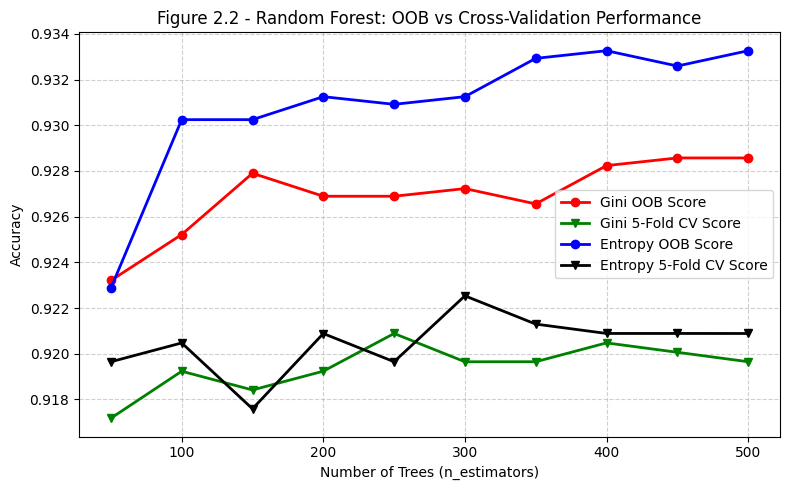

In [2001]:
# plot results from previous step
plt.figure(figsize=(8, 5))
plt.plot(n_estimator, oobScores_gini, color='red', marker='o',  label='Gini OOB Score', linewidth=2)
plt.plot(n_estimator, oobScores_cv,  color='green', marker='v', label='Gini 5-Fold CV Score', linewidth=2)
plt.plot(n_estimator, oobScores_ent, color='blue', marker='o',  label='Entropy OOB Score', linewidth=2)
plt.plot(n_estimator, oobScores_cv_ent,  color='black', marker='v', label='Entropy 5-Fold CV Score', linewidth=2)
plt.title('Figure 2.2 - Random Forest: OOB vs Cross-Validation Performance')
plt.xlabel('Number of Trees (n_estimators)')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [2002]:

# print comparison table
cv_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Gini 5-Fold CV Score' : oobScores_cv })
gini_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Gini' : oobScores_gini })
ent_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Ent' : oobScores_ent })
ent_cv_df = pd.DataFrame({ 'n_estimator' : n_estimator, 'Ent 5-Fold CV Score' : oobScores_cv_ent })
oob_scores = pd.merge(cv_df, ent_cv_df, left_on='n_estimator', right_on='n_estimator', how='left')
oob_scores = pd.merge(ent_df, oob_scores, left_on='n_estimator', right_on='n_estimator', how='left')
oob_scores = pd.merge(gini_df, oob_scores, left_on='n_estimator', right_on='n_estimator', how='left')
print('\nTable 2.2: OBB Score Differences by criterion \n', oob_scores)



Table 2.2: OBB Score Differences by criterion 
    n_estimator      Gini       Ent  Gini 5-Fold CV Score  Ent 5-Fold CV Score
0           50  0.923206  0.922871              0.917177             0.919648
1          100  0.925218  0.930248              0.919233             0.920472
2          150  0.927901  0.930248              0.918413             0.917588
3          200  0.926895  0.931254              0.919236             0.920884
4          250  0.926895  0.930919              0.920886             0.919649
5          300  0.927230  0.931254              0.919648             0.922535
6          350  0.926559  0.932931              0.919649             0.921297
7          400  0.928236  0.933266              0.920474             0.920887
8          450  0.928571  0.932596              0.920063             0.920887
9          500  0.928571  0.933266              0.919649             0.920886


In [2003]:
# retrain model using max depth from above

rf0_pipe = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('rf', RandomForestClassifier(
        n_estimators=400,
        criterion='entropy', 
        random_state=13,
        oob_score=True,
        n_jobs=-1
    ))
])


# lets get the best depth
param_dist = {
    'rf__max_depth': randint(2, 40),           
    'rf__min_samples_split': randint(2, 20),
    'rf__min_samples_leaf': randint(1, 10),
    'rf__max_features': ['sqrt', 'log2', None]
}

random_search = RandomizedSearchCV(
    estimator=rf0_pipe,
    param_distributions=param_dist,
    n_iter=40,                     
    scoring='f1_macro',          
    cv=5,
    random_state=13,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best params:", random_search.best_params_)
print("Best score:", random_search.best_score_)
best_depth = random_search.best_params_['rf__max_depth']

Best params: {'rf__max_depth': 38, 'rf__max_features': None, 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 5}
Best score: 0.9152917032693864


In [2004]:
# train using the above
rf_model = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('classifier', RandomForestClassifier(
        n_estimators=400,
        criterion='entropy', 
        random_state=13,
        oob_score=True,
        max_depth=38, 
        min_samples_leaf=2, 
        min_samples_split=5,
        n_jobs=-1
    ))
])


rf_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [2005]:
# Evaluate Model
eval_df = evaluate_model(rf_model, model_name="RF1")


RF1

Confusion Matrix for RF1
 [[619  20]
 [ 79 323]]

Classification Report for RF1:
               precision    recall  f1-score   support

           0       0.89      0.97      0.93       639
           1       0.94      0.80      0.87       402

    accuracy                           0.90      1041
   macro avg       0.91      0.89      0.90      1041
weighted avg       0.91      0.90      0.90      1041


Top Features 
                                           importance
num__total_approved                         0.240551
num__weighted_avg_grade                     0.154727
num__total_evaluations                      0.055666
cat__tuition_fees_up_to_date_decoded_No     0.046746
cat__tuition_fees_up_to_date_decoded_Yes    0.045176
num__age_at_enrollment                      0.035963
cat__scholarship_holder_decoded_No          0.027244
cat__scholarship_holder_decoded_Yes         0.023777
num__total_enrolled                         0.022665
cat__gender_decoded_Female             

### 2.2 XGBoost

In [2006]:
# XGBoost

xgb0_pipe = ImbPipeline([
    ('preprocessor', preprocessor2),
    ('smote', SMOTE(random_state=13)),
    ('classifier', XGBClassifier(
        n_estimators=200,
        max_depth=5,
        learning_rate=0.1,
        eval_metric='logloss',
        random_state=13
    ))
])

xgb0_pipe.fit(X_train, y_train)

scores = cross_val_score(xgb0_pipe, X_train, y_train, cv=10, scoring='f1_macro')
print("Mean F1-macro CV score:", scores.mean())

# Evaluate Model
eval_df = evaluate_model(xgb0_pipe, model_name="XG0")

Mean F1-macro CV score: 0.9184148920079416

XG0

Confusion Matrix for XG0
 [[608  31]
 [ 67 335]]

Classification Report for XG0:
               precision    recall  f1-score   support

           0       0.90      0.95      0.93       639
           1       0.92      0.83      0.87       402

    accuracy                           0.91      1041
   macro avg       0.91      0.89      0.90      1041
weighted avg       0.91      0.91      0.90      1041


Top Features 
                                                     importance
num__total_approved                                   0.152841
cat__tuition_fees_up_to_date_decoded_No               0.100898
num__total_enrolled                                   0.031039
cat__debtor_decoded_No                                0.028775
cat__course_decoded_Other                             0.026420
cat__gender_decoded_Female                            0.022932
cat__daytimeevening_attendance_decoded_Daytime        0.021546
cat__course_decoded_Jo

In [2007]:
# Use RandomSearch to Tune 

param_dist = {
    'classifier__n_estimators': [100, 200, 300, 500],
    'classifier__max_depth': [3, 4, 5, 6, 8],
    'classifier__learning_rate': [0.01, 0.05, 0.1, 0.2],
    'classifier__subsample': [0.6, 0.7, 0.8, 1.0],
    'classifier__colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'classifier__min_child_weight': [1, 3, 5, 7],
    'classifier__gamma': [0, 0.1, 0.3, 0.5],
    'classifier__reg_lambda': [1, 1.5, 2, 5, 10],
    'classifier__reg_alpha': [0, 0.1, 0.5, 1],
}


random_search = RandomizedSearchCV(
    estimator=xgb0_pipe,
    param_distributions=param_dist,
    n_iter=20,                
    scoring='f1_macro',      
    cv=10,
    verbose=2,
    n_jobs=-1,
    random_state=13
)

# === Fit Search ===
random_search.fit(X_train, y_train)

print("Best score:", random_search.best_score_)
print("Best params:", random_search.best_params_)



Fitting 10 folds for each of 20 candidates, totalling 200 fits
[CV] END classifier__colsample_bytree=0.7, classifier__gamma=0.3, classifier__learning_rate=0.2, classifier__max_depth=8, classifier__min_child_weight=3, classifier__n_estimators=200, classifier__reg_alpha=0.1, classifier__reg_lambda=5, classifier__subsample=0.6; total time=   0.3s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.3, classifier__learning_rate=0.01, classifier__max_depth=3, classifier__min_child_weight=5, classifier__n_estimators=200, classifier__reg_alpha=0.1, classifier__reg_lambda=1, classifier__subsample=0.8; total time=   0.2s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0, classifier__learning_rate=0.1, classifier__max_depth=3, classifier__min_child_weight=7, classifier__n_estimators=500, classifier__reg_alpha=1, classifier__reg_lambda=2, classifier__subsample=0.6; total time=   0.2s
[CV] END classifier__colsample_bytree=0.8, classifier__gamma=0.5, classifier__learning_rate

In [2008]:

# Evaluate Model

xgb1_model = random_search.best_estimator_
eval_df = evaluate_model(xgb1_model, model_name="XG1")


XG1

Confusion Matrix for XG1
 [[603  36]
 [ 70 332]]

Classification Report for XG1:
               precision    recall  f1-score   support

           0       0.90      0.94      0.92       639
           1       0.90      0.83      0.86       402

    accuracy                           0.90      1041
   macro avg       0.90      0.88      0.89      1041
weighted avg       0.90      0.90      0.90      1041


Top Features 
                                                     importance
num__total_approved                                   0.156009
cat__tuition_fees_up_to_date_decoded_No               0.122393
cat__debtor_decoded_No                                0.040759
cat__course_decoded_Other                             0.029493
num__total_enrolled                                   0.029071
cat__course_decoded_Social Service                    0.022834
cat__marital_status_decoded_Single                    0.021649
cat__scholarship_holder_decoded_No                    0.020892
ca

In [2009]:
# Show model metrics
print(eval_df)

      model_name  accuracy  recall_no  recall_yes     f1_no    f1_yes       auc     auprc
0  Decision Tree  0.884726   0.949922    0.781095  0.910045  0.839572  0.894189  0.877795
1            RF0  0.907781   0.965571    0.815920  0.927820  0.872340  0.945098  0.943208
2            RF1  0.904899   0.968701    0.803483  0.925954  0.867114  0.945363  0.943184
3            XG0  0.905860   0.951487    0.833333  0.925419  0.872396  0.937036  0.938810
4            XG1  0.898175   0.943662    0.825871  0.919207  0.862338  0.937453  0.936987


### 3.3 Neural Networds

In [2017]:
print (X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 2427 entries, 3589 to 1306
Data columns (total 28 columns):
 #   Column                             Non-Null Count  Dtype   
---  ------                             --------------  -----   
 0   application_order                  2427 non-null   int64   
 1   age_at_enrollment                  2427 non-null   int64   
 2   unemployment_rate                  2427 non-null   float64 
 3   inflation_rate                     2427 non-null   float64 
 4   gdp                                2427 non-null   float64 
 5   marital_status_decoded             2427 non-null   category
 6   application_mode_decoded           2427 non-null   category
 7   course_decoded                     2427 non-null   category
 8   daytimeevening_attendance_decoded  2427 non-null   category
 9   previous_qualification_decoded     2427 non-null   category
 10  nationality_decoded                2427 non-null   category
 11  mothers_qualification_decoded      2427 non-n

In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()


X_train_prep = preprocessor2.fit_transform(X_train)
X_test_prep  = preprocessor2.transform(X_test)

print(X_train_prep)


y_train_enc = le.fit_transform(y_train)  
y_test_enc = le.transform(y_test)

# y_train_prep = to_categorical(y_train_enc)
# y_test_prep = to_categorical(y_test_enc)





[[ 0.          0.          1.         ... -1.58005792 -0.21306115 -2.3116219 ]
 [ 0.          0.          1.         ...  1.0280955  -0.21306115  0.06311255]
 [ 0.          0.          1.         ...  0.37605714 -0.21306115  0.39427899]
 ...
 [ 0.          0.          1.         ...  0.37605714 -0.21306115  0.20453594]
 [ 0.          1.          0.         ... -0.4389908  -0.21306115  0.30143715]
 [ 0.          0.          1.         ...  2.00615303 -0.21306115  0.6663921 ]]


In [ ]:


input_dim = X_train_prep.shape[1]
print("Input dim:", input_dim)

classes = np.unique(y_train)
cw = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weight = {c: w for c, w in zip(classes, cw)}
print("Class weight:", class_weight)

def make_model(input_dim):
    model = models.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    model.add(layers.Dense(128, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.4))
    model.add(layers.Dense(64, activation='relu',
                           kernel_regularizer=regularizers.l2(1e-4)))
    model.add(layers.Dropout(0.3))
    
    model.add(layers.Dense(1, activation='sigmoid'))
   # model.add(layers.Dense(2, activation='softmax'))
    model.compile(
        loss='binary_crossentropy',
        #loss='categorical_crossentropy',
        optimizer='adam',
        # optimizer=tf.keras.optimizers.Adam(1e-3),
        metrics=['accuracy', 'AUC', 'Precision', 'Recall']
    )
    return model

tensor_model = make_model(input_dim)

es = callbacks.EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)
rlp = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=6)

# --- train ---
history = tensor_model.fit(
    X_train_prep,
    y_train_enc,
    validation_split=0.15,     
    epochs=200,
    batch_size=32,
    class_weight=class_weight, 
    callbacks=[es, rlp],
    verbose=2
)


Input dim: 92
Class weight: {np.int64(0): np.float64(0.8138832997987927), np.int64(1): np.float64(1.296474358974359)}
Epoch 1/200
65/65 - 1s - 21ms/step - AUC: 0.8643 - Precision: 0.7259 - Recall: 0.7429 - accuracy: 0.7992 - loss: 0.4892 - val_AUC: 0.9352 - val_Precision: 0.8662 - val_Recall: 0.8193 - val_accuracy: 0.8603 - val_loss: 0.3404 - learning_rate: 0.0010
Epoch 2/200
65/65 - 0s - 932us/step - AUC: 0.9408 - Precision: 0.8636 - Recall: 0.8468 - accuracy: 0.8928 - loss: 0.3107 - val_AUC: 0.9563 - val_Precision: 0.9329 - val_Recall: 0.8373 - val_accuracy: 0.8986 - val_loss: 0.2688 - learning_rate: 0.0010
Epoch 3/200
65/65 - 0s - 903us/step - AUC: 0.9450 - Precision: 0.8557 - Recall: 0.8545 - accuracy: 0.8919 - loss: 0.2962 - val_AUC: 0.9600 - val_Precision: 0.9245 - val_Recall: 0.8855 - val_accuracy: 0.9151 - val_loss: 0.2503 - learning_rate: 0.0010
Epoch 4/200
65/65 - 0s - 887us/step - AUC: 0.9542 - Precision: 0.8864 - Recall: 0.8714 - accuracy: 0.9103 - loss: 0.2664 - val_AUC: 0

In [ ]:

# --- evaluate ---
tensor_model.evaluate(X_test_prep, y_test_enc, verbose=2)


In [ ]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(input_dim,)),
    tf.keras.layers.Dense(64, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(1, activation='sigmoid')  # binary classification
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC()]
)
